# Fall Detection Pipeline

In [ ]:
!pip install -q ultralytics opencv-python matplotlib pandas scikit-learn tqdm lap 


In [2]:
import os
import re
import json
import math
import random
import warnings
from pathlib import Path
from collections import defaultdict, deque

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

from ultralytics import YOLO

warnings.filterwarnings("ignore")


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

/home/zmey1/anaconda3/envs/fallgpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce GTX 1650


In [3]:
import torch

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch cuda version:", torch.version.cuda)
print("cuDNN version:", torch.backends.cudnn.version())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory allocated:", torch.cuda.memory_allocated() / 1024**2, "MB")
    print("GPU memory reserved:", torch.cuda.memory_reserved() / 1024**2, "MB")

torch version: 2.5.1+cu121
cuda available: True
torch cuda version: 12.1
cuDNN version: 90100
GPU: NVIDIA GeForce GTX 1650
GPU memory allocated: 0.0 MB
GPU memory reserved: 0.0 MB


In [4]:
CONFIG = {
    # -----------------------------
    # Paths
    # -----------------------------
    "dataset_root": "archive",   
    "annotation_root": "archive/Coffee_room_01/Coffee_room_01/Annotation_files",  
    "output_root": "outputs",
    # -----------------------------
    # Video
    # -----------------------------
    "video_exts": [".avi", ".mp4", ".mov", ".mkv"],
    "frame_skip": 1,

    # -----------------------------
    # YOLO pose
    # -----------------------------
    "yolo_model_name": "yolov8n-pose.pt",
    "imgsz": 640,
    "conf_thresh": 0.25,
    "iou_thresh": 0.45,

    # Use "botsort.yaml" or "bytetrack.yaml"
    "tracker_yaml": "botsort.yaml",

    # -----------------------------
    # Keypoints
    # YOLOv8 pose uses COCO 17 keypoints
    # -----------------------------
    "num_keypoints": 17,
    "kpt_conf_thresh": 0.30,
    "min_visible_kpts": 6,

    # shoulders and hips in COCO format:
    # left shoulder 5, right shoulder 6, left hip 11, right hip 12
    "torso_kpt_indices": [5, 6, 11, 12],
    "min_visible_torso_kpts": 2,

    # -----------------------------
    # Temporal windows
    # -----------------------------
    "seq_len": 30,
    "window_stride": 5,
    "min_fall_overlap_frames": 5,

    # -----------------------------
    # CNN training
    # -----------------------------
    "batch_size": 64,
    "epochs": 15,
    "lr": 5e-4,
    "weight_decay": 5e-4,
    "val_size": 0.2,

    # -----------------------------
    # Occlusion augmentation
    # -----------------------------
    "use_occlusion_aug": True,
    "keypoint_dropout_prob": 0.10,

    # -----------------------------
    # Inference decision
    # -----------------------------
    "fall_prob_threshold": 0.50,
    "confirm_windows": 3,

    # -----------------------------
    # Display
    # -----------------------------
    "font_scale": 0.5,
    "font_thickness": 1,
}

In [5]:
OUTPUT_ROOT = Path(CONFIG["output_root"])
TRACKS_DIR = OUTPUT_ROOT / "tracks"
CHECKPOINTS_DIR = OUTPUT_ROOT / "checkpoints"
LOGS_DIR = OUTPUT_ROOT / "logs"

for folder in [OUTPUT_ROOT, TRACKS_DIR, CHECKPOINTS_DIR, LOGS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Folders ready:")
print(TRACKS_DIR)
print(CHECKPOINTS_DIR)
print(LOGS_DIR)

Folders ready:
outputs/tracks
outputs/checkpoints
outputs/logs


In [6]:
def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)


def load_json(path):
    with open(path, "r") as f:
        return json.load(f)


def natural_sort_key(s):
    s = str(s)
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", s)]


def extract_numbers_from_line(line):
    nums = re.findall(r"[-+]?\d*\.\d+|[-+]?\d+", line)
    out = []
    for x in nums:
        if "." in x:
            out.append(float(x))
        else:
            out.append(int(x))
    return out


def xywh_center_to_xyxy(cx, cy, w, h):
    x1 = cx - w / 2
    y1 = cy - h / 2
    x2 = cx + w / 2
    y2 = cy + h / 2
    return [float(x1), float(y1), float(x2), float(y2)]


def xyxy_to_xywh(box):
    x1, y1, x2, y2 = box
    w = max(1.0, x2 - x1)
    h = max(1.0, y2 - y1)
    cx = x1 + w / 2
    cy = y1 + h / 2
    return cx, cy, w, h


def clamp_bbox_xyxy(box, img_w, img_h):
    x1, y1, x2, y2 = box
    x1 = max(0, min(float(x1), img_w - 1))
    y1 = max(0, min(float(y1), img_h - 1))
    x2 = max(0, min(float(x2), img_w - 1))
    y2 = max(0, min(float(y2), img_h - 1))
    return [x1, y1, x2, y2]


def compute_iou_xyxy(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    iw = max(0.0, ix2 - ix1)
    ih = max(0.0, iy2 - iy1)
    inter = iw * ih

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)

    union = area_a + area_b - inter
    if union <= 0:
        return 0.0

    return inter / union


def read_video_metadata(video_path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    cap.release()

    return {
        "fps": fps,
        "frame_count": frame_count,
        "width": width,
        "height": height,
    }


def show_bgr_image(img_bgr, title=None, figsize=(6, 4)):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(img_rgb)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()


def draw_bbox(frame, bbox, color=(0, 255, 0), label=None, thickness=2):
    x1, y1, x2, y2 = [int(round(v)) for v in bbox]
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, thickness)

    if label is not None:
        cv2.putText(
            frame,
            str(label),
            (x1, max(0, y1 - 8)),
            cv2.FONT_HERSHEY_SIMPLEX,
            CONFIG["font_scale"],
            color,
            CONFIG["font_thickness"],
            cv2.LINE_AA,
        )

    return frame

In [7]:
def collect_video_files(dataset_root, video_exts):
    dataset_root = Path(dataset_root)

    videos = []
    for ext in video_exts:
        videos.extend(dataset_root.rglob(f"*{ext}"))

    videos = [v for v in videos if "Annotation_files" not in str(v)]
    videos = sorted(videos, key=natural_sort_key)

    return videos


def find_matching_annotation(video_path, annotation_root):
    video_path = Path(video_path)
    annotation_root = Path(annotation_root)

    stem = video_path.stem
    scene_name = video_path.parent.name.lower().replace(" ", "_")

    direct = list(annotation_root.rglob(f"{stem}.txt"))
    if len(direct) == 1:
        return direct[0]

    if len(direct) > 1:
        for candidate in direct:
            candidate_str = str(candidate).lower().replace(" ", "_")
            if scene_name in candidate_str:
                return candidate
        return direct[0]

    stem_clean = stem.lower().replace(" ", "").replace("_", "")
    all_txts = list(annotation_root.rglob("*.txt"))

    for txt in all_txts:
        txt_clean = txt.stem.lower().replace(" ", "").replace("_", "")
        if txt_clean == stem_clean:
            return txt

    return None


def build_dataset_index(config):
    videos = collect_video_files(config["dataset_root"], config["video_exts"])

    rows = []
    for video_path in videos:
        annotation_path = find_matching_annotation(video_path, config["annotation_root"])

        rows.append({
            "video_path": str(video_path),
            "video_name": video_path.name,
            "video_stem": video_path.stem,
            "scene": video_path.parent.name,
            "annotation_path": str(annotation_path) if annotation_path is not None else None,
        })

    return pd.DataFrame(rows)


dataset_df = build_dataset_index(CONFIG)

print("Total videos found:", len(dataset_df))
display(dataset_df.head())

missing = dataset_df[dataset_df["annotation_path"].isna()]
print("Missing annotations:", len(missing))

if len(missing) > 0:
    display(missing)

Total videos found: 190


,video_path,video_name,video_stem,scene,annotation_path
0,archive/Coffee_room_01/Coffee_room_01/Videos/v...,video (1).mp4,video (1),Videos,archive/Coffee_room_01/Coffee_room_01/Annotati...
1,archive/Coffee_room_01/Coffee_room_01/Videos/v...,video (2).mp4,video (2),Videos,archive/Coffee_room_01/Coffee_room_01/Annotati...
2,archive/Coffee_room_01/Coffee_room_01/Videos/v...,video (3).mp4,video (3),Videos,archive/Coffee_room_01/Coffee_room_01/Annotati...
3,archive/Coffee_room_01/Coffee_room_01/Videos/v...,video (4).mp4,video (4),Videos,archive/Coffee_room_01/Coffee_room_01/Annotati...
4,archive/Coffee_room_01/Coffee_room_01/Videos/v...,video (5).mp4,video (5),Videos,archive/Coffee_room_01/Coffee_room_01/Annotati...


Missing annotations: 34


,video_path,video_name,video_stem,scene,annotation_path
48,archive/Coffee_room_02/Coffee_room_02/Videos/v...,video (49).mp4,video (49),Videos,None
49,archive/Coffee_room_02/Coffee_room_02/Videos/v...,video (50).mp4,video (50),Videos,None
50,archive/Coffee_room_02/Coffee_room_02/Videos/v...,video (51).mp4,video (51),Videos,None
51,archive/Coffee_room_02/Coffee_room_02/Videos/v...,video (52).mp4,video (52),Videos,None
52,archive/Coffee_room_02/Coffee_room_02/Videos/v...,video (53).mp4,video (53),Videos,None
53,archive/Coffee_room_02/Coffee_room_02/Videos/v...,video (54).mp4,video (54),Videos,None
54,archive/Coffee_room_02/Coffee_room_02/Videos/v...,video (55).mp4,video (55),Videos,None
55,archive/Coffee_room_02/Coffee_room_02/Videos/v...,video (56).mp4,video (56),Videos,None
56,archive/Coffee_room_02/Coffee_room_02/Videos/v...,video (57).mp4,video (57),Videos,None
57,archive/Coffee_room_02/Coffee_room_02/Videos/v...,video (58).mp4,video (58),Videos,None


## convert all avi to mp4

kernel crash was happening due to missing audio track in avi so we are converting everything to silent(no audio) mp4

In [8]:
import subprocess
import shutil
from pathlib import Path
from tqdm.auto import tqdm

def find_ffmpeg():
    ffmpeg_path = shutil.which("ffmpeg")
    ffprobe_path = shutil.which("ffprobe")

    if ffmpeg_path is None:
        raise RuntimeError(
            "ffmpeg not found. Install it first:\n"
            "sudo apt update && sudo apt install ffmpeg -y"
        )

    if ffprobe_path is None:
        raise RuntimeError(
            "ffprobe not found. It usually comes with ffmpeg:\n"
            "sudo apt update && sudo apt install ffmpeg -y"
        )

    return ffmpeg_path, ffprobe_path


def is_valid_video_ffprobe(video_path, ffprobe_path):
    """
    Checks whether ffprobe can read at least one video stream.
    """
    video_path = Path(video_path)

    cmd = [
        ffprobe_path,
        "-v", "error",
        "-select_streams", "v:0",
        "-show_entries", "stream=width,height,nb_frames,duration",
        "-of", "json",
        str(video_path),
    ]

    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )

    if result.returncode != 0:
        return False

    return video_path.exists() and video_path.stat().st_size > 0


def convert_avi_to_mp4_inplace(
    avi_path,
    ffmpeg_path,
    ffprobe_path,
    delete_original=True,
    overwrite=False,
):
    """
    Converts one AVI file to MP4 in the same folder.
    Removes audio using -an to avoid mp3float/header issues.
    Deletes original AVI only after MP4 is validated.
    """
    avi_path = Path(avi_path)
    mp4_path = avi_path.with_suffix(".mp4")

    if mp4_path.exists() and mp4_path.stat().st_size > 0 and not overwrite:
        if is_valid_video_ffprobe(mp4_path, ffprobe_path):
            if delete_original and avi_path.exists():
                avi_path.unlink()
            return {
                "avi_path": str(avi_path),
                "mp4_path": str(mp4_path),
                "status": "already_exists_valid",
            }

    temp_mp4_path = avi_path.with_suffix(".tmp.mp4")

    if temp_mp4_path.exists():
        temp_mp4_path.unlink()

    cmd = [
        ffmpeg_path,
        "-y",
        "-hide_banner",
        "-loglevel", "error",
        "-i", str(avi_path),

        # take only first video stream
        "-map", "0:v:0",

        # remove audio completely to avoid mp3float/header missing crashes
        "-an",

        # stable mp4 output
        "-c:v", "libx264",
        "-crf", "18",
        "-preset", "veryfast",
        "-pix_fmt", "yuv420p",
        "-movflags", "+faststart",

        str(temp_mp4_path),
    ]

    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )

    if result.returncode != 0:
        if temp_mp4_path.exists():
            temp_mp4_path.unlink()

        return {
            "avi_path": str(avi_path),
            "mp4_path": str(mp4_path),
            "status": "conversion_failed",
            "error": result.stderr,
        }

    if not is_valid_video_ffprobe(temp_mp4_path, ffprobe_path):
        if temp_mp4_path.exists():
            temp_mp4_path.unlink()

        return {
            "avi_path": str(avi_path),
            "mp4_path": str(mp4_path),
            "status": "validation_failed",
        }

    if mp4_path.exists():
        mp4_path.unlink()

    temp_mp4_path.rename(mp4_path)

    if delete_original and avi_path.exists():
        avi_path.unlink()

    return {
        "avi_path": str(avi_path),
        "mp4_path": str(mp4_path),
        "status": "converted_deleted_avi" if delete_original else "converted_kept_avi",
    }


def convert_all_avi_to_mp4_and_delete(config, overwrite=False):
    dataset_root = Path(config["dataset_root"])

    avi_files = sorted(
        [
            p for p in dataset_root.rglob("*.avi")
            if "Annotation_files" not in str(p)
        ],
        key=natural_sort_key,
    )

    print("AVI files found:", len(avi_files))

    if len(avi_files) == 0:
        print("No AVI files to convert.")
        return pd.DataFrame()

    ffmpeg_path, ffprobe_path = find_ffmpeg()

    rows = []

    for avi_path in tqdm(avi_files, desc="Converting AVI to MP4"):
        row = convert_avi_to_mp4_inplace(
            avi_path=avi_path,
            ffmpeg_path=ffmpeg_path,
            ffprobe_path=ffprobe_path,
            delete_original=True,
            overwrite=overwrite,
        )
        rows.append(row)

    conversion_df = pd.DataFrame(rows)

    print("\nConversion summary:")
    display(conversion_df["status"].value_counts().to_frame("count"))

    failed = conversion_df[
        conversion_df["status"].isin(["conversion_failed", "validation_failed"])
    ]

    if len(failed) > 0:
        print("\nFailed conversions:")
        display(failed)

    remaining_avi = list(dataset_root.rglob("*.avi"))
    remaining_avi = [p for p in remaining_avi if "Annotation_files" not in str(p)]

    print("Remaining AVI files:", len(remaining_avi))

    return conversion_df


conversion_df = convert_all_avi_to_mp4_and_delete(CONFIG, overwrite=False)

AVI files found: 0
No AVI files to convert.


In [9]:
CONFIG["video_exts"] = [".mp4", ".mov", ".mkv"]

print("Updated video_exts:", CONFIG["video_exts"])

dataset_df = build_dataset_index(CONFIG)

print("Total videos found:", len(dataset_df))
print("Missing annotations:", dataset_df["annotation_path"].isna().sum())
display(dataset_df.head())

Updated video_exts: ['.mp4', '.mov', '.mkv']
Total videos found: 190
Missing annotations: 34


,video_path,video_name,video_stem,scene,annotation_path
0,archive/Coffee_room_01/Coffee_room_01/Videos/v...,video (1).mp4,video (1),Videos,archive/Coffee_room_01/Coffee_room_01/Annotati...
1,archive/Coffee_room_01/Coffee_room_01/Videos/v...,video (2).mp4,video (2),Videos,archive/Coffee_room_01/Coffee_room_01/Annotati...
2,archive/Coffee_room_01/Coffee_room_01/Videos/v...,video (3).mp4,video (3),Videos,archive/Coffee_room_01/Coffee_room_01/Annotati...
3,archive/Coffee_room_01/Coffee_room_01/Videos/v...,video (4).mp4,video (4),Videos,archive/Coffee_room_01/Coffee_room_01/Annotati...
4,archive/Coffee_room_01/Coffee_room_01/Videos/v...,video (5).mp4,video (5),Videos,archive/Coffee_room_01/Coffee_room_01/Annotati...


In [10]:
def parse_le2i_annotation(txt_path):
    """
    LE2I annotation format:

    Line 1: fall start frame
    Line 2: fall end frame

    Remaining lines:
    frame_idx, flag, x1, y1, x2, y2

    Example:
    5,1,292,152,311,240

    means:
    frame_idx = 5
    flag = 1
    bbox = [292, 152, 311, 240]
    """
    txt_path = Path(txt_path)

    with open(txt_path, "r") as f:
        raw_lines = [line.strip() for line in f.readlines() if line.strip()]

    if len(raw_lines) < 2:
        raise ValueError(f"Annotation file too short: {txt_path}")

    fall_start = int(extract_numbers_from_line(raw_lines[0])[0])
    fall_end = int(extract_numbers_from_line(raw_lines[1])[0])

    frame_boxes = {}

    for line in raw_lines[2:]:
        nums = extract_numbers_from_line(line)

        if len(nums) < 6:
            continue

        frame_idx = int(nums[0])
        flag = int(nums[1])

        x1 = float(nums[2])
        y1 = float(nums[3])
        x2 = float(nums[4])
        y2 = float(nums[5])

        # skip invalid empty boxes like 0,0,0,0
        if x2 <= x1 or y2 <= y1:
            continue

        frame_boxes[frame_idx] = {
            "flag": flag,
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "xyxy": [x1, y1, x2, y2],
        }

    return {
        "fall_start": fall_start,
        "fall_end": fall_end,
        "frame_boxes": frame_boxes,
    }

test annotations

In [11]:
sample_row = dataset_df.dropna(subset=["annotation_path"]).iloc[0]

print("Sample video:", sample_row["video_path"])
print("Matched annotation:", sample_row["annotation_path"])

with open(sample_row["annotation_path"], "r") as f:
    lines = [line.rstrip("\n") for line in f.readlines()]

print("\nFirst 25 raw annotation lines:")
for i, line in enumerate(lines[:25]):
    print(i, repr(line), "=>", extract_numbers_from_line(line))

Sample video: archive/Coffee_room_01/Coffee_room_01/Videos/video (1).mp4
Matched annotation: archive/Coffee_room_01/Coffee_room_01/Annotation_files/video (1).txt

First 25 raw annotation lines:
0 '48' => [48]
1 '80' => [80]
2 '1,1,0,0,0,0' => [1, 1, 0, 0, 0, 0]
3 '2,1,0,0,0,0' => [2, 1, 0, 0, 0, 0]
4 '3,1,0,0,0,0' => [3, 1, 0, 0, 0, 0]
5 '4,1,0,0,0,0' => [4, 1, 0, 0, 0, 0]
6 '5,1,292,152,311,240' => [5, 1, 292, 152, 311, 240]
7 '6,1,292,152,311,240' => [6, 1, 292, 152, 311, 240]
8 '7,1,292,152,311,240' => [7, 1, 292, 152, 311, 240]
9 '8,1,285,131,315,241' => [8, 1, 285, 131, 315, 241]
10 '9,1,284,114,315,239' => [9, 1, 284, 114, 315, 239]
11 '10,1,284,114,315,239' => [10, 1, 284, 114, 315, 239]
12 '11,1,279,68,312,241' => [11, 1, 279, 68, 312, 241]
13 '12,1,275,63,315,240' => [12, 1, 275, 63, 315, 240]
14 '13,1,268,66,316,241' => [13, 1, 268, 66, 316, 241]
15 '14,1,268,66,316,241' => [14, 1, 268, 66, 316, 241]
16 '15,1,258,64,314,241' => [15, 1, 258, 64, 314, 241]
17 '16,1,244,61,315,2

# Imp Point
annotations as given in dataset considers only fall like motion if person stays down lying it considers it normal

so here we change the annotations to also include that lying down on floor as fall

Video: archive/Coffee_room_01/Coffee_room_01/Videos/video (1).mp4
FPS: 25.0
Frames: 157
Size: (320, 240)
Fall interval: 48 to 80
Preview frames: [38, 48, 64, 80, 90]


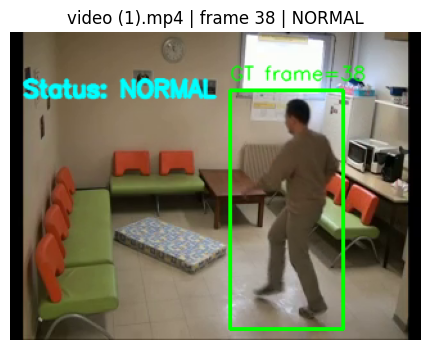

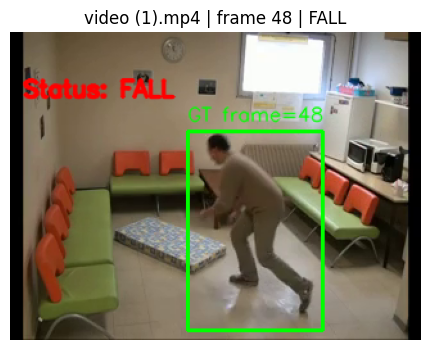

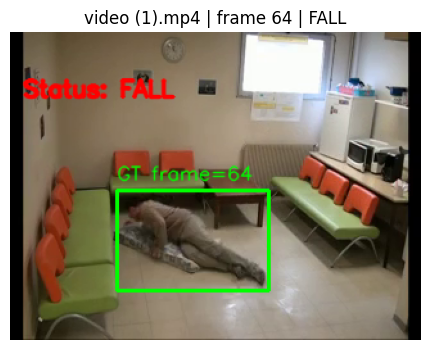

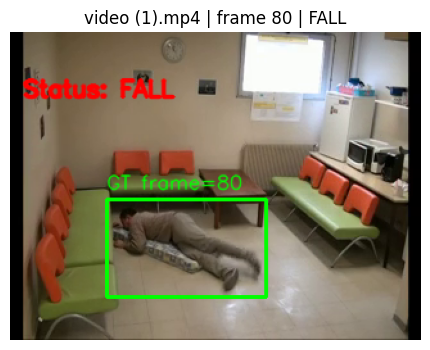

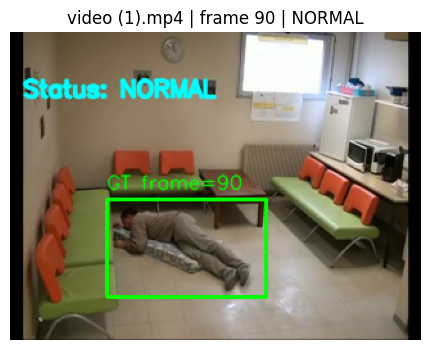

In [12]:
def preview_gt_boxes_on_video_safe(video_path, annotation_path, num_frames=5):
    ann = parse_le2i_annotation(annotation_path)
    meta = read_video_metadata(video_path)

    fall_start = int(ann["fall_start"])
    fall_end = int(ann["fall_end"])
    frame_count = int(meta["frame_count"])

    print("Video:", video_path)
    print("FPS:", meta["fps"])
    print("Frames:", frame_count)
    print("Size:", (meta["width"], meta["height"]))
    print("Fall interval:", fall_start, "to", fall_end)

    candidate_frames = [
        max(1, fall_start - 10),
        fall_start,
        (fall_start + fall_end) // 2,
        fall_end,
        min(frame_count, fall_end + 10),
    ]

    candidate_frames = sorted(set(candidate_frames[:num_frames]))
    candidate_set = set(candidate_frames)

    print("Preview frames:", candidate_frames)

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    frame_idx = 1

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        if frame_idx in candidate_set:
            h_img, w_img = frame.shape[:2]

            if frame_idx in ann["frame_boxes"]:
                b = ann["frame_boxes"][frame_idx]
                gt_bbox = clamp_bbox_xyxy(b["xyxy"], w_img, h_img)
                draw_bbox(frame, gt_bbox, color=(0, 255, 0), label=f"GT frame={frame_idx}")

            status = "FALL" if fall_start <= frame_idx <= fall_end else "NORMAL"
            color = (0, 0, 255) if status == "FALL" else (255, 255, 0)

            cv2.putText(
                frame,
                f"Status: {status}",
                (10, 50),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                color,
                2,
                cv2.LINE_AA,
            )

            show_bgr_image(
                frame,
                title=f"{Path(video_path).name} | frame {frame_idx} | {status}",
                figsize=(6, 4),
            )

        if frame_idx >= max(candidate_frames):
            break

        frame_idx += 1

    cap.release()
    plt.close("all")


sample_row = dataset_df.dropna(subset=["annotation_path"]).iloc[0]

preview_gt_boxes_on_video_safe(
    video_path=sample_row["video_path"],
    annotation_path=sample_row["annotation_path"],
    num_frames=5,
)

In [13]:
pose_model = YOLO(CONFIG["yolo_model_name"])
print("Loaded:", CONFIG["yolo_model_name"])

Loaded: yolov8n-pose.pt


In [14]:
def extract_pose_tracks_from_video(video_path, save_path=None, max_frames=None):
    """
    Runs YOLOv8n-pose + tracker on one video.

    Saves records:
    - frame_idx
    - track_id
    - bbox_xyxy
    - keypoints: list of 17 [x, y, conf]
    - det_conf
    """

    video_path = str(video_path)

    results = pose_model.track(
        source=video_path,
        stream=True,
        persist=True,
        tracker=CONFIG["tracker_yaml"],
        imgsz=CONFIG["imgsz"],
        conf=CONFIG["conf_thresh"],
        iou=CONFIG["iou_thresh"],
        verbose=False,
    )

    records = []
    frame_idx = 1

    for r in tqdm(results, desc=f"Tracking {Path(video_path).name}"):
        if max_frames is not None and frame_idx > max_frames:
            break

        if CONFIG["frame_skip"] > 1 and ((frame_idx - 1) % CONFIG["frame_skip"] != 0):
            frame_idx += 1
            continue

        if r.boxes is None or len(r.boxes) == 0:
            frame_idx += 1
            continue

        boxes_xyxy = r.boxes.xyxy.detach().cpu().numpy()

        if r.boxes.conf is not None:
            det_confs = r.boxes.conf.detach().cpu().numpy()
        else:
            det_confs = np.ones(len(boxes_xyxy), dtype=np.float32)

        if r.boxes.id is not None:
            track_ids = r.boxes.id.detach().cpu().numpy().astype(int)
        else:
            track_ids = np.arange(len(boxes_xyxy)).astype(int)

        if r.keypoints is not None and r.keypoints.data is not None:
            kpts_data = r.keypoints.data.detach().cpu().numpy()
        else:
            kpts_data = np.zeros(
                (len(boxes_xyxy), CONFIG["num_keypoints"], 3),
                dtype=np.float32,
            )

        for i in range(len(boxes_xyxy)):
            kpts = kpts_data[i]

            if kpts.shape[-1] == 2:
                conf_col = np.ones((kpts.shape[0], 1), dtype=np.float32)
                kpts = np.concatenate([kpts, conf_col], axis=-1)

            record = {
                "video_path": video_path,
                "video_name": Path(video_path).name,
                "frame_idx": int(frame_idx),
                "track_id": int(track_ids[i]),
                "bbox_xyxy": [float(x) for x in boxes_xyxy[i].tolist()],
                "keypoints": [[float(v) for v in kp] for kp in kpts.tolist()],
                "det_conf": float(det_confs[i]),
            }

            records.append(record)

        frame_idx += 1

    if save_path is not None:
        save_json(records, save_path)

    return records

def make_video_uid(video_path, dataset_root):
    rel = Path(video_path).relative_to(Path(dataset_root))
    return re.sub(r"[^A-Za-z0-9]+", "_", str(rel.with_suffix(""))).strip("_")

dataset_df["video_uid"] = dataset_df["video_path"].apply(
    lambda p: make_video_uid(p, CONFIG["dataset_root"])
)

display(dataset_df[["video_uid", "video_name", "video_path"]].head())

def get_track_save_path_from_uid(video_uid):
    return TRACKS_DIR / f"{video_uid}_tracks.json"

sample_row = dataset_df.dropna(subset=["annotation_path"]).iloc[0]

sample_video = sample_row["video_path"]
sample_video_uid = sample_row["video_uid"]

sample_track_path = get_track_save_path_from_uid(sample_video_uid)

sample_records = extract_pose_tracks_from_video(
    video_path=sample_video,
    save_path=sample_track_path,
    max_frames=None,
)

print("Saved:", sample_track_path)
print("Num records:", len(sample_records))
print("First record:")
sample_records[0] if len(sample_records) > 0 else None

,video_uid,video_name,video_path
0,Coffee_room_01_Coffee_room_01_Videos_video_1,video (1).mp4,archive/Coffee_room_01/Coffee_room_01/Videos/v...
1,Coffee_room_01_Coffee_room_01_Videos_video_2,video (2).mp4,archive/Coffee_room_01/Coffee_room_01/Videos/v...
2,Coffee_room_01_Coffee_room_01_Videos_video_3,video (3).mp4,archive/Coffee_room_01/Coffee_room_01/Videos/v...
3,Coffee_room_01_Coffee_room_01_Videos_video_4,video (4).mp4,archive/Coffee_room_01/Coffee_room_01/Videos/v...
4,Coffee_room_01_Coffee_room_01_Videos_video_5,video (5).mp4,archive/Coffee_room_01/Coffee_room_01/Videos/v...


Tracking video (1).mp4: 157it [00:04, 36.70it/s]

Saved: outputs/tracks/Coffee_room_01_Coffee_room_01_Videos_video_1_tracks.json
Num records: 161
First record:


{'video_path': 'archive/Coffee_room_01/Coffee_room_01/Videos/video (1).mp4',
 'video_name': 'video (1).mp4',
 'frame_idx': 2,
 'track_id': 0,
 'bbox_xyxy': [224.0902099609375,
  95.75022888183594,
  288.03375244140625,
  151.88882446289062],
 'keypoints': [[266.15936279296875, 135.36947631835938, 0.10246116667985916],
  [267.9440612792969, 134.5543212890625, 0.10755093395709991],
  [266.2716369628906, 133.7891387939453, 0.09814590215682983],
  [268.4913635253906, 135.26686096191406, 0.2847583293914795],
  [266.525390625, 133.58023071289062, 0.16341285407543182],
  [265.7135314941406, 135.14385986328125, 0.22206249833106995],
  [268.2728271484375, 133.44259643554688, 0.1990446299314499],
  [266.94854736328125, 126.89325714111328, 0.10881592333316803],
  [273.8353271484375, 125.51659393310547, 0.11170324683189392],
  [271.83612060546875, 127.8199691772461, 0.15633654594421387],
  [278.2326965332031, 129.53872680664062, 0.14889195561408997],
  [258.0006103515625, 121.49559783935547, 0.238

In [15]:
def summarize_track_records(records):
    if len(records) == 0:
        print("No records.")
        return pd.DataFrame()

    df = pd.DataFrame([
        {
            "frame_idx": r["frame_idx"],
            "track_id": r["track_id"],
            "det_conf": r["det_conf"],
        }
        for r in records
    ])

    summary = (
        df.groupby("track_id")
        .agg(
            num_detections=("frame_idx", "count"),
            first_frame=("frame_idx", "min"),
            last_frame=("frame_idx", "max"),
            mean_conf=("det_conf", "mean"),
        )
        .reset_index()
        .sort_values("num_detections", ascending=False)
    )

    return summary


track_summary = summarize_track_records(sample_records)
display(track_summary.head(10))

,track_id,num_detections,first_frame,last_frame,mean_conf
1,3,148,10,157,0.879038
2,8,10,75,96,0.266086
0,0,3,2,9,0.305729


In [16]:
def match_gt_to_track(records, annotation):
    """
    Matches GT bbox to the YOLO track using average IoU over frames.

    Returns:
    - best_track_id
    - scores dataframe
    """
    frame_boxes = annotation["frame_boxes"]

    track_iou_sum = defaultdict(float)
    track_iou_count = defaultdict(int)

    for rec in records:
        frame_idx = int(rec["frame_idx"])

        if frame_idx not in frame_boxes:
            continue

        gt_box = frame_boxes[frame_idx]["xyxy"]
        pred_box = rec["bbox_xyxy"]
        iou = compute_iou_xyxy(pred_box, gt_box)

        track_id = int(rec["track_id"])
        track_iou_sum[track_id] += iou
        track_iou_count[track_id] += 1

    rows = []
    for track_id in track_iou_sum:
        count = track_iou_count[track_id]
        mean_iou = track_iou_sum[track_id] / max(1, count)
        rows.append({
            "track_id": track_id,
            "mean_iou": mean_iou,
            "matched_frames": count,
        })

    scores_df = pd.DataFrame(rows)

    if len(scores_df) == 0:
        return None, scores_df

    scores_df = scores_df.sort_values(["mean_iou", "matched_frames"], ascending=False)
    best_track_id = int(scores_df.iloc[0]["track_id"])

    return best_track_id, scores_df


sample_ann = parse_le2i_annotation(sample_row["annotation_path"])
best_track_id, match_scores = match_gt_to_track(sample_records, sample_ann)

print("Best matched track:", best_track_id)
display(match_scores.head(10))

Best matched track: 3


,track_id,mean_iou,matched_frames
1,3,0.762347,148
0,0,0.514086,1
2,8,0.000000,10


In [17]:
def count_visible_keypoints(keypoints, conf_thresh=None):
    if conf_thresh is None:
        conf_thresh = CONFIG["kpt_conf_thresh"]

    kpts = np.asarray(keypoints, dtype=np.float32)
    conf = kpts[:, 2]

    return int(np.sum(conf >= conf_thresh))


def count_visible_torso_keypoints(keypoints, conf_thresh=None):
    if conf_thresh is None:
        conf_thresh = CONFIG["kpt_conf_thresh"]

    kpts = np.asarray(keypoints, dtype=np.float32)
    conf = kpts[:, 2]

    torso_indices = CONFIG["torso_kpt_indices"]
    return int(np.sum(conf[torso_indices] >= conf_thresh))


def is_pose_good_enough(keypoints):
    visible = count_visible_keypoints(keypoints)
    torso_visible = count_visible_torso_keypoints(keypoints)

    return (
        visible >= CONFIG["min_visible_kpts"]
        and torso_visible >= CONFIG["min_visible_torso_kpts"]
    )


def normalize_keypoints_with_bbox(keypoints, bbox_xyxy):
    """
    Normalizes keypoints relative to the detected person's bbox.

    Input:
    - keypoints: 17 x 3, x,y,conf
    - bbox_xyxy: x1,y1,x2,y2

    Output:
    - 17 x 3, normalized x,y,conf
    """
    kpts = np.asarray(keypoints, dtype=np.float32).copy()
    x1, y1, x2, y2 = bbox_xyxy

    w = max(1.0, x2 - x1)
    h = max(1.0, y2 - y1)

    kpts[:, 0] = (kpts[:, 0] - x1) / w
    kpts[:, 1] = (kpts[:, 1] - y1) / h

    kpts[:, 0] = np.clip(kpts[:, 0], 0.0, 1.0)
    kpts[:, 1] = np.clip(kpts[:, 1], 0.0, 1.0)
    kpts[:, 2] = np.clip(kpts[:, 2], 0.0, 1.0)

    return kpts


def record_to_feature_vector(record):
    """
    Per-frame feature vector:
    - normalized keypoints: 17 x 3 = 51
    - bbox/motion-independent features = 7

    Total = 58 features
    """
    norm_kpts = normalize_keypoints_with_bbox(
        keypoints=record["keypoints"],
        bbox_xyxy=record["bbox_xyxy"],
    )

    kpt_features = norm_kpts.reshape(-1).astype(np.float32)

    x1, y1, x2, y2 = record["bbox_xyxy"]
    cx, cy, w, h = xyxy_to_xywh([x1, y1, x2, y2])

    # LE2I videos are 320x240, but use record dimensions if available later.
    frame_w = 320.0
    frame_h = 240.0

    bbox_cx = cx / frame_w
    bbox_cy = cy / frame_h
    bbox_w = w / frame_w
    bbox_h = h / frame_h
    aspect = w / max(h, 1.0)
    area = (w * h) / (frame_w * frame_h)

    visible_ratio = count_visible_keypoints(record["keypoints"]) / CONFIG["num_keypoints"]

    bbox_features = np.array([
        bbox_cx,
        bbox_cy,
        bbox_w,
        bbox_h,
        aspect,
        area,
        visible_ratio,
    ], dtype=np.float32)

    return np.concatenate([kpt_features, bbox_features], axis=0)

In [18]:
def group_records_by_track(records):
    tracks = defaultdict(list)

    for rec in records:
        tracks[int(rec["track_id"])].append(rec)

    for tid in tracks:
        tracks[tid] = sorted(tracks[tid], key=lambda x: x["frame_idx"])

    return tracks


def label_window_binary(start_frame, end_frame, fall_start, fall_end):
    """
    Returns:
    0 = normal
    1 = fall
    """
    overlap_start = max(start_frame, fall_start)
    overlap_end = min(end_frame, fall_end)

    overlap = max(0, overlap_end - overlap_start + 1)

    if overlap >= CONFIG["min_fall_overlap_frames"]:
        return 1

    return 0

def get_bbox_aspect_ratio_from_ann_box(box_info):
    x1, y1, x2, y2 = box_info["xyxy"]
    w = max(1.0, x2 - x1)
    h = max(1.0, y2 - y1)
    return w / h


def is_fallen_like_bbox(box_info, aspect_thresh=1.15):
    """
    Returns True if GT bbox looks like a fallen/horizontal person.
    This is only used for training-label construction from LE2I annotations.
    """
    aspect = get_bbox_aspect_ratio_from_ann_box(box_info)
    return aspect >= aspect_thresh


def label_window_binary_with_fallen_state(
    start_frame,
    end_frame,
    annotation,
    min_fall_overlap_frames=5,
    min_fallen_state_frames=5,
    fallen_aspect_thresh=1.15,
):
    """
    Binary label:
    0 = normal
    1 = fall

    A window is fall if:
    - it overlaps the annotated fall-motion interval enough, OR
    - after fall_start, the GT bbox looks fallen/horizontal for enough frames.

    This avoids labeling all frames after fall_start as fall forever.
    If the person stands back up, later windows can become normal.
    """

    fall_start = int(annotation["fall_start"])
    fall_end = int(annotation["fall_end"])
    frame_boxes = annotation["frame_boxes"]

    # 1. Check overlap with annotated fall-motion interval.
    overlap_start = max(start_frame, fall_start)
    overlap_end = min(end_frame, fall_end)
    fall_motion_overlap = max(0, overlap_end - overlap_start + 1)

    if fall_motion_overlap >= min_fall_overlap_frames:
        return 1

    # 2. Check fallen-state posture after fall_start.
    fallen_state_count = 0

    for frame_idx in range(start_frame, end_frame + 1):
        if frame_idx < fall_start:
            continue

        if frame_idx not in frame_boxes:
            continue

        box_info = frame_boxes[frame_idx]

        if is_fallen_like_bbox(
            box_info,
            aspect_thresh=fallen_aspect_thresh,
        ):
            fallen_state_count += 1

    if fallen_state_count >= min_fallen_state_frames:
        return 1

    return 0

def extract_windows_from_track(track_records, annotation, video_name, video_uid):
    seq_len = CONFIG["seq_len"]
    stride = CONFIG["window_stride"]

    if len(track_records) < seq_len:
        return [], [], []

    X = []
    y = []
    meta = []

    fall_start = int(annotation["fall_start"])
    fall_end = int(annotation["fall_end"])

    for start_idx in range(0, len(track_records) - seq_len + 1, stride):
        window_records = track_records[start_idx:start_idx + seq_len]

        start_frame = int(window_records[0]["frame_idx"])
        end_frame = int(window_records[-1]["frame_idx"])

        features = []
        good_pose_count = 0

        for rec in window_records:
            features.append(record_to_feature_vector(rec))
            if is_pose_good_enough(rec["keypoints"]):
                good_pose_count += 1

        features = np.stack(features, axis=0)  # T x 51
        label = label_window_binary_with_fallen_state(
            start_frame=start_frame,
            end_frame=end_frame,
            annotation=annotation,
            min_fall_overlap_frames=CONFIG["min_fall_overlap_frames"],
            min_fallen_state_frames=5,
            fallen_aspect_thresh=1.15,
        )

        X.append(features)
        y.append(label)
        meta.append({
            "video_uid": video_uid,
            "video_name": video_uid,
            "track_id": int(window_records[0]["track_id"]),
            "start_frame": start_frame,
            "end_frame": end_frame,
            "good_pose_count": good_pose_count,
        })

    return X, y, meta


tracks = group_records_by_track(sample_records)
matched_track_records = tracks[best_track_id]

X_sample, y_sample, meta_sample = extract_windows_from_track(
    matched_track_records,
    sample_ann,
    sample_row["video_name"],
    sample_row["video_uid"],
)

print("Windows:", len(X_sample))
print("X shape example:", X_sample[0].shape if len(X_sample) else None)
print("Label counts:", pd.Series(y_sample).value_counts().to_dict())
print("First meta:", meta_sample[0] if len(meta_sample) else None)

Windows: 24
X shape example: (30, 58)
Label counts: {1: 21, 0: 3}
First meta: {'video_uid': 'Coffee_room_01_Coffee_room_01_Videos_video_1', 'video_name': 'Coffee_room_01_Coffee_room_01_Videos_video_1', 'track_id': 3, 'start_frame': 10, 'end_frame': 39, 'good_pose_count': 29}


In [19]:
def load_or_extract_records(video_path, video_uid):
    save_path = get_track_save_path_from_uid(video_uid)

    if save_path.exists():
        return load_json(save_path)

    return extract_pose_tracks_from_video(
        video_path=video_path,
        save_path=save_path,
        max_frames=None,
    )


def build_window_dataset_from_le2i(dataset_df, max_videos=None):
    all_X = []
    all_y = []
    all_meta = []

    usable_df = dataset_df.dropna(subset=["annotation_path"]).reset_index(drop=True)

    if max_videos is not None:
        usable_df = usable_df.iloc[:max_videos]

    for _, row in tqdm(usable_df.iterrows(), total=len(usable_df), desc="Building windows"):
        video_path = row["video_path"]
        annotation_path = row["annotation_path"]
        video_name = row["video_name"]
        video_uid = row["video_uid"]

        try:
            ann = parse_le2i_annotation(annotation_path)

            records = load_or_extract_records(
                video_path=video_path,
                video_uid=video_uid,
            )

            if len(records) == 0:
                print("No records:", video_name)
                continue

            best_tid, scores = match_gt_to_track(records, ann)

            if best_tid is None:
                print("Could not match GT to track:", video_name)
                continue

            tracks = group_records_by_track(records)

            if best_tid not in tracks:
                print("Best track missing after grouping:", video_name)
                continue

            X, y, meta = extract_windows_from_track(
                track_records=tracks[best_tid],
                annotation=ann,
                video_name=video_name,
                video_uid=video_uid,
            )

            for m in meta:
                m["video_uid"] = video_uid
                m["video_path"] = video_path
                m["matched_track_id"] = best_tid

            all_X.extend(X)
            all_y.extend(y)
            all_meta.extend(meta)

        except Exception as e:
            print("Error processing:", video_name)
            print(e)

    X_arr = np.asarray(all_X, dtype=np.float32)
    y_arr = np.asarray(all_y, dtype=np.int64)
    meta_df = pd.DataFrame(all_meta)

    return X_arr, y_arr, meta_df

# First test with a small number.
X, y, meta_df = build_window_dataset_from_le2i(
    dataset_df,
    max_videos=None
)

print("X:", X.shape)
print("y:", y.shape)
print("Label counts:", pd.Series(y).value_counts().to_dict())
display(meta_df.head())

Building windows: 100%|██████████| 156/156 [00:23<00:00,  6.52it/s]

X: (6468, 30, 58)
y: (6468,)
Label counts: {0: 4886, 1: 1582}


,video_uid,video_name,track_id,start_frame,end_frame,good_pose_count,video_path,matched_track_id
0,Coffee_room_01_Coffee_room_01_Videos_video_1,Coffee_room_01_Coffee_room_01_Videos_video_1,3,10,39,29,archive/Coffee_room_01/Coffee_room_01/Videos/v...,3
1,Coffee_room_01_Coffee_room_01_Videos_video_1,Coffee_room_01_Coffee_room_01_Videos_video_1,3,15,44,30,archive/Coffee_room_01/Coffee_room_01/Videos/v...,3
2,Coffee_room_01_Coffee_room_01_Videos_video_1,Coffee_room_01_Coffee_room_01_Videos_video_1,3,20,49,30,archive/Coffee_room_01/Coffee_room_01/Videos/v...,3
3,Coffee_room_01_Coffee_room_01_Videos_video_1,Coffee_room_01_Coffee_room_01_Videos_video_1,3,25,54,30,archive/Coffee_room_01/Coffee_room_01/Videos/v...,3
4,Coffee_room_01_Coffee_room_01_Videos_video_1,Coffee_room_01_Coffee_room_01_Videos_video_1,3,30,59,30,archive/Coffee_room_01/Coffee_room_01/Videos/v...,3


## Dataset Exploration Summary

### GMDCSA-24 Dataset

**Folder structure:**
```
GMDCSA24-A-Dataset-for-Human-Fall-Detection-in-Videos-master/
├── Subject 1/  ├── ADL/ (16 mp4)  ├── ADL.csv
│               ├── Fall/ (16 mp4) └── Fall.csv
├── Subject 2/  (23 ADL, 25 Fall)
├── Subject 3/  (22 ADL, 21 Fall)
└── Subject 4/  (20 ADL, 17 Fall)
```
**Total:** 79 Fall videos, 81 ADL videos (160 total)  
**Video specs:** MP4, 1280×720, ~30 fps  

**Annotation format:** CSV per subject with columns `File Name`, `Length (seconds)`, `Time of Recording`, `Attire`, `Description`, `Classes`.  
The `Classes` column contains **second-level timestamps** per activity:
```
Falling (SW)[3.4 to 6]; Sitting[0 to 3.4]
```
This gives `fall_start` and `fall_end` in seconds (→ frames via FPS).  
**No per-frame bounding boxes exist.**

**Fall types:** Falling (SW)=sideways, Falling (FW)=forward, Falling (BW)=backward  
**ADL types:** Sitting, Sleeping, Walking, Standing, Exercising, Reading, Writing, Drinking, Eating

**Sample Fall.csv rows (Subject 1):**
| File | Classes |
|------|--------|
| 01.mp4 | Falling (SW)[3.4 to 6]; Sitting[0 to 3.4] |
| 08.mp4 | Falling (FW)[0.8 to 4]; Walking[0 to 0.8] |
| 11.mp4 | Falling (BW)[1 to 6]; Standing[0 to 1] |

**Adaptation needed (Case B — timestamps only):**  
- Parse `Classes` regex → fall_start/fall_end in frames using actual FPS  
- No IoU GT matching; select primary track (most detections + highest mean confidence)  
- ADL videos: `fall_start=fall_end=999999` (all normal)  
- Normalize bbox features with actual 1280×720, not Le2i hardcoded 320×240

---

### UR Fall Detection Dataset

**Folder structure:**
```
archive_ur/UR_fall_detection_dataset_cam0_rgb/
├── fall-01-cam0-rgb/  ← 160 PNG frames at 640×480
│   ├── fall-01-cam0-rgb-001.png
│   └── ...
├── fall-02-cam0-rgb/ ... fall-30-cam0-rgb/
├── adl-01-cam0-rgb/  ← 150 PNG frames
└── ... adl-40-cam0-rgb/
```
**Total:** 30 fall sequences, 40 ADL sequences  
**Format:** PNG image sequences only (no video files). Resolution 640×480, assumed 30 fps.  
**Frames per sequence:** Fall 55–215 (mean ~100). ADL 70–400 (mean ~224).  
**Annotations:** None — folder name is the only ground truth label.

**Adaptation needed (Case B — no timestamps):**  
- Stitch PNGs → MP4 via ffmpeg at 30 fps (cached per sequence)  
- Fall sequences: `fall_start=1`, `fall_end=total_frames` (full sequence = fall event)  
- ADL sequences: `fall_start=fall_end=999999` (all normal)  
- No IoU GT matching; select primary track  
- Normalize bbox with actual 640×480

---

### Differences from Le2i

| Aspect | Le2i | GMDCSA-24 | UR Fall |
|--------|------|-----------|---------|
| Format | AVI→MP4, 320×240 | MP4, 1280×720 | PNG→MP4, 640×480 |
| Annotation | Per-frame bbox + fall frames | Second-level timestamps | None (folder label) |
| GT matching | IoU vs annotated bbox | Primary track | Primary track |
| Fall precision | Exact motion frames | ~0.1 s resolution | Full sequence |
| Videos | ~48 usable | 160 (79 fall, 81 ADL) | 70 (30 fall, 40 ADL) |


## GMDCSA-24 Dataset Adapter


In [20]:
# ── Shared helpers for multi-dataset adapters ─────────────────────────────────

def record_to_feature_vector_v2(record):
    """
    Same as record_to_feature_vector but reads frame_w/frame_h from the record
    (keys added during extraction), defaulting to Le2i's 320×240 when absent.
    This ensures correct bbox feature normalization across different resolutions.
    """
    norm_kpts = normalize_keypoints_with_bbox(
        keypoints=record["keypoints"],
        bbox_xyxy=record["bbox_xyxy"],
    )
    kpt_features = norm_kpts.reshape(-1).astype(np.float32)

    x1, y1, x2, y2 = record["bbox_xyxy"]
    cx, cy, w, h = xyxy_to_xywh([x1, y1, x2, y2])

    frame_w = float(record.get("frame_w", 320.0))
    frame_h = float(record.get("frame_h", 240.0))

    bbox_cx = cx / frame_w
    bbox_cy = cy / frame_h
    bbox_w  = w  / frame_w
    bbox_h  = h  / frame_h
    aspect  = w  / max(h, 1.0)
    area    = (w * h) / (frame_w * frame_h)
    visible_ratio = count_visible_keypoints(record["keypoints"]) / CONFIG["num_keypoints"]

    bbox_features = np.array(
        [bbox_cx, bbox_cy, bbox_w, bbox_h, aspect, area, visible_ratio],
        dtype=np.float32,
    )
    return np.concatenate([kpt_features, bbox_features], axis=0)


def extract_windows_from_track_v2(track_records, annotation, video_uid):
    """
    Identical to extract_windows_from_track but uses record_to_feature_vector_v2
    so bbox features are correctly scaled for non-Le2i resolutions.
    """
    seq_len = CONFIG["seq_len"]
    stride  = CONFIG["window_stride"]

    if len(track_records) < seq_len:
        return [], [], []

    X, y, meta = [], [], []

    for start_idx in range(0, len(track_records) - seq_len + 1, stride):
        window = track_records[start_idx : start_idx + seq_len]
        start_frame = int(window[0]["frame_idx"])
        end_frame   = int(window[-1]["frame_idx"])

        features = []
        good_pose_count = 0
        for rec in window:
            features.append(record_to_feature_vector_v2(rec))
            if is_pose_good_enough(rec["keypoints"]):
                good_pose_count += 1

        features = np.stack(features, axis=0)

        label = label_window_binary_with_fallen_state(
            start_frame=start_frame,
            end_frame=end_frame,
            annotation=annotation,
            min_fall_overlap_frames=CONFIG["min_fall_overlap_frames"],
            min_fallen_state_frames=5,
            fallen_aspect_thresh=1.15,
        )

        X.append(features)
        y.append(label)
        meta.append({
            "video_uid":       video_uid,
            "video_name":      video_uid,
            "track_id":        int(window[0]["track_id"]),
            "start_frame":     start_frame,
            "end_frame":       end_frame,
            "good_pose_count": good_pose_count,
        })

    return X, y, meta


def select_primary_track(records):
    """
    Pick the most prominent YOLO track — highest detection count,
    tie-broken by mean detection confidence.
    Used instead of IoU GT matching when no per-frame bboxes exist.
    """
    if not records:
        return None
    tracks = group_records_by_track(records)
    if not tracks:
        return None
    return max(
        tracks.keys(),
        key=lambda tid: (
            len(tracks[tid]),
            float(np.mean([r["det_conf"] for r in tracks[tid]])),
        ),
    )


def load_or_extract_records_with_dims(video_path, video_uid, frame_w, frame_h):
    """
    Load cached track JSON or run YOLO extraction, then patch
    frame_w/frame_h into every record so record_to_feature_vector_v2
    can normalize bbox features to the correct resolution.
    """
    save_path = get_track_save_path_from_uid(video_uid)

    if save_path.exists():
        records = load_json(save_path)
        if records and "frame_w" not in records[0]:
            for rec in records:
                rec["frame_w"] = frame_w
                rec["frame_h"] = frame_h
            save_json(records, save_path)
        return records

    records = extract_pose_tracks_from_video(
        video_path=video_path,
        save_path=None,
        max_frames=None,
    )

    for rec in records:
        rec["frame_w"] = frame_w
        rec["frame_h"] = frame_h

    save_json(records, save_path)
    return records


print("Shared adapter helpers defined.")


Shared adapter helpers defined.


In [21]:
# ── GMDCSA-24 ── config, CSV parser, index builder ────────────────────────────

GMDCSA24_ROOT = Path("GMDCSA24-A-Dataset-for-Human-Fall-Detection-in-Videos-master")


def parse_gmdcsa24_classes_column(classes_str, fps):
    """
    Extract fall_start / fall_end (frame numbers) from a Classes cell like:
      ' Falling (SW)[3.4 to 6]; Sitting[0 to 3.4]'
    Returns (999999, 999999) if no falling event is found.
    """
    import re as _re
    if not isinstance(classes_str, str):
        return 999999, 999999
    pattern = r"[Ff]all(?:ing)?\s*\([^)]*\)\s*\[\s*([0-9.]+)\s+to\s+([0-9.]+)\s*\]"
    m = _re.search(pattern, classes_str)
    if not m:
        return 999999, 999999
    start_frame = max(1, round(float(m.group(1)) * fps))
    end_frame   = round(float(m.group(2)) * fps)
    return start_frame, end_frame


def build_gmdcsa24_index():
    rows = []
    for subj_num in [1, 2, 3, 4]:
        subj_dir = GMDCSA24_ROOT / f"Subject {subj_num}"
        for kind in ["Fall", "ADL"]:
            video_dir = subj_dir / kind
            csv_path  = subj_dir / f"{kind}.csv"
            if not csv_path.exists() or not video_dir.exists():
                continue

            csv_df = pd.read_csv(csv_path)
            for _, row in csv_df.iterrows():
                video_path = video_dir / row["File Name"]
                if not video_path.exists():
                    continue

                cap = cv2.VideoCapture(str(video_path))
                fps          = cap.get(cv2.CAP_PROP_FPS) or 30.0
                total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                frame_w      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
                frame_h      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
                cap.release()

                if kind == "Fall":
                    fall_start, fall_end = parse_gmdcsa24_classes_column(
                        row.get(" Classes", ""), fps
                    )
                else:
                    fall_start, fall_end = 999999, 999999

                video_uid = (
                    f"gmdcsa24_subject{subj_num}_{kind.lower()}_"
                    + video_path.stem
                )

                rows.append({
                    "video_path":   str(video_path),
                    "video_uid":    video_uid,
                    "subject":      subj_num,
                    "kind":         kind,
                    "fps":          fps,
                    "total_frames": total_frames,
                    "frame_w":      frame_w,
                    "frame_h":      frame_h,
                    "fall_start":   fall_start,
                    "fall_end":     fall_end,
                    "annotation":   {
                        "fall_start": fall_start,
                        "fall_end":   fall_end,
                        "frame_boxes": {},
                    },
                })

    return pd.DataFrame(rows)


gmdcsa24_index_df = build_gmdcsa24_index()
print("GMDCSA-24 index:", len(gmdcsa24_index_df), "videos")
print(gmdcsa24_index_df.groupby("kind")[["kind"]].count().rename(columns={"kind": "count"}))
display(gmdcsa24_index_df[["video_uid", "kind", "fps", "total_frames", "fall_start", "fall_end"]].head(6))


GMDCSA-24 index: 160 videos
      count
kind       
ADL      81
Fall     79


,video_uid,kind,fps,total_frames,fall_start,fall_end
0,gmdcsa24_subject1_fall_01,Fall,29.567987,203,101,177
1,gmdcsa24_subject1_fall_02,Fall,29.672659,189,56,178
2,gmdcsa24_subject1_fall_03,Fall,29.721530,176,74,149
3,gmdcsa24_subject1_fall_04,Fall,29.427771,146,68,118
4,gmdcsa24_subject1_fall_05,Fall,29.704830,174,53,149
5,gmdcsa24_subject1_fall_06,Fall,29.663521,169,65,148


In [22]:
# ── GMDCSA-24 ── build window dataset ────────────────────────────────────────

def build_window_dataset_from_gmdcsa24(index_df):
    _n_feat = CONFIG["num_keypoints"] * 3 + 7
    all_X, all_y, all_meta = [], [], []

    for _, row in tqdm(index_df.iterrows(), total=len(index_df), desc="GMDCSA-24 windows"):
        video_path  = row["video_path"]
        video_uid   = row["video_uid"]
        annotation  = row["annotation"]
        frame_w     = int(row["frame_w"])
        frame_h     = int(row["frame_h"])

        try:
            records = load_or_extract_records_with_dims(
                video_path=video_path,
                video_uid=video_uid,
                frame_w=frame_w,
                frame_h=frame_h,
            )
            if not records:
                print(f"  No records: {video_uid}")
                continue

            best_tid = select_primary_track(records)
            if best_tid is None:
                print(f"  No tracks: {video_uid}")
                continue

            tracks = group_records_by_track(records)
            X_v, y_v, meta_v = extract_windows_from_track_v2(
                track_records=tracks[best_tid],
                annotation=annotation,
                video_uid=video_uid,
            )
            for m in meta_v:
                m["dataset"] = "gmdcsa24"

            all_X.extend(X_v)
            all_y.extend(y_v)
            all_meta.extend(meta_v)

        except Exception as e:
            print(f"  Error {video_uid}: {e}")

    if not all_X:
        return (
            np.zeros((0, CONFIG["seq_len"], _n_feat), dtype=np.float32),
            np.zeros(0, dtype=np.int64),
            pd.DataFrame(),
        )

    return (
        np.asarray(all_X, dtype=np.float32),
        np.asarray(all_y, dtype=np.int64),
        pd.DataFrame(all_meta),
    )


X_gmd, y_gmd, meta_gmd = build_window_dataset_from_gmdcsa24(gmdcsa24_index_df)
print(f"GMDCSA-24 windows: {X_gmd.shape[0]}")
print(f"  fall={int((y_gmd==1).sum())}  normal={int((y_gmd==0).sum())}")
display(meta_gmd.groupby(["dataset", (y_gmd)]).size().to_frame("count"))


GMDCSA-24 windows: 100%|██████████| 160/160 [00:19<00:00,  8.34it/s]

GMDCSA-24 windows: 5509
  fall=1380  normal=4129


count
dataset          
gmdcsa24 0   4129
         1   1380

## UR Fall Detection Dataset Adapter


In [26]:
# ── UR Fall ── stitch PNG sequences → MP4 (cached) ────────────────────────────

URFALL_ROOT    = Path("archive_ur/UR_fall_detection_dataset_cam0_rgb")
URFALL_MP4_DIR = OUTPUT_ROOT / "urfall_mp4"
URFALL_MP4_DIR.mkdir(parents=True, exist_ok=True)


def stitch_sequence_to_mp4(seq_dir, output_mp4, fps=30):
    """Convert a directory of PNGs to an MP4 via ffmpeg. Skips if output exists."""
    import re as _re
    seq_dir    = Path(seq_dir)
    output_mp4 = Path(output_mp4)

    if output_mp4.exists() and output_mp4.stat().st_size > 0:
        return {"status": "already_exists", "path": str(output_mp4)}

    pngs = sorted(seq_dir.glob("*.png"))
    if not pngs:
        return {"status": "no_pngs", "path": str(output_mp4)}

    first_name  = pngs[0].name
    pattern     = _re.sub(r"(\d+)\.png$", "%03d.png", first_name)
    start_num   = int(_re.search(r"(\d+)\.png$", first_name).group(1))
    ffmpeg_path, _ = find_ffmpeg()  # uses notebook helper; raises if not found

    cmd = [
        ffmpeg_path, "-y",
        "-hide_banner", "-loglevel", "error",
        "-framerate", str(fps),
        "-start_number", str(start_num),
        "-i", str(seq_dir / pattern),
        "-c:v", "libx264",
        "-crf", "18",
        "-pix_fmt", "yuv420p",
        "-movflags", "+faststart",
        str(output_mp4),
    ]
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    if result.returncode != 0:
        return {"status": "failed", "error": result.stderr[:300], "path": str(output_mp4)}
    return {"status": "created", "path": str(output_mp4)}


def convert_all_ur_fall_sequences(ur_root=URFALL_ROOT, out_dir=URFALL_MP4_DIR, fps=30):
    """Batch-stitch all UR Fall sequences to MP4. Cached."""
    seq_dirs = sorted([d for d in ur_root.iterdir() if d.is_dir()], key=lambda d: d.name)
    rows = []
    for seq_dir in tqdm(seq_dirs, desc="Stitching UR Fall PNGs → MP4"):
        out_mp4 = out_dir / f"{seq_dir.name}.mp4"
        row     = stitch_sequence_to_mp4(seq_dir, out_mp4, fps=fps)
        row["seq_name"] = seq_dir.name
        rows.append(row)
    df = pd.DataFrame(rows)
    print("Status summary:")
    print(df["status"].value_counts().to_string())
    failed = df[df["status"] == "failed"]
    if len(failed):
        print("Failed sequences:")
        display(failed)
    return df


urfall_conversion_df = convert_all_ur_fall_sequences()
print(f"MP4 files ready: {len(list(URFALL_MP4_DIR.glob('*.mp4')))}")


Stitching UR Fall PNGs → MP4:   0%|          | 0/70 [00:00<?, ?it/s]

Stitching UR Fall PNGs → MP4: 100%|██████████| 70/70 [02:23<00:00,  2.05s/it]

Status summary:
status
created    70
MP4 files ready: 70


In [27]:
# ── UR Fall ── index builder + window dataset ─────────────────────────────────

def build_urfall_index():
    rows = []
    mp4_files = sorted(URFALL_MP4_DIR.glob("*.mp4"), key=lambda p: p.name)

    for mp4_path in mp4_files:
        seq_name = mp4_path.stem          # e.g. fall-01-cam0-rgb
        is_fall  = seq_name.startswith("fall-")

        cap = cv2.VideoCapture(str(mp4_path))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frame_w      = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        frame_h      = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        cap.release()

        if total_frames < CONFIG["seq_len"]:
            continue

        fall_start = 1        if is_fall else 999999
        fall_end   = total_frames if is_fall else 999999

        video_uid = "urfall_" + seq_name.replace("-", "_")

        rows.append({
            "video_path":   str(mp4_path),
            "video_uid":    video_uid,
            "seq_name":     seq_name,
            "is_fall":      is_fall,
            "total_frames": total_frames,
            "frame_w":      frame_w,
            "frame_h":      frame_h,
            "fall_start":   fall_start,
            "fall_end":     fall_end,
            "annotation":   {
                "fall_start":  fall_start,
                "fall_end":    fall_end,
                "frame_boxes": {},
            },
        })

    return pd.DataFrame(rows)


def build_window_dataset_from_urfall(index_df):
    _n_feat = CONFIG["num_keypoints"] * 3 + 7
    all_X, all_y, all_meta = [], [], []

    for _, row in tqdm(index_df.iterrows(), total=len(index_df), desc="UR Fall windows"):
        video_path  = row["video_path"]
        video_uid   = row["video_uid"]
        annotation  = row["annotation"]
        frame_w     = int(row["frame_w"])
        frame_h     = int(row["frame_h"])

        try:
            records = load_or_extract_records_with_dims(
                video_path=video_path,
                video_uid=video_uid,
                frame_w=frame_w,
                frame_h=frame_h,
            )
            if not records:
                print(f"  No records: {video_uid}")
                continue

            best_tid = select_primary_track(records)
            if best_tid is None:
                print(f"  No tracks: {video_uid}")
                continue

            tracks = group_records_by_track(records)
            X_v, y_v, meta_v = extract_windows_from_track_v2(
                track_records=tracks[best_tid],
                annotation=annotation,
                video_uid=video_uid,
            )
            for m in meta_v:
                m["dataset"] = "urfall"

            all_X.extend(X_v)
            all_y.extend(y_v)
            all_meta.extend(meta_v)

        except Exception as e:
            print(f"  Error {video_uid}: {e}")

    if not all_X:
        return (
            np.zeros((0, CONFIG["seq_len"], _n_feat), dtype=np.float32),
            np.zeros(0, dtype=np.int64),
            pd.DataFrame(),
        )

    return (
        np.asarray(all_X, dtype=np.float32),
        np.asarray(all_y, dtype=np.int64),
        pd.DataFrame(all_meta),
    )


urfall_index_df = build_urfall_index()
print(f"UR Fall index: {len(urfall_index_df)} sequences")
print(urfall_index_df.groupby("is_fall")[["is_fall"]].count().rename(columns={"is_fall": "count"}))

X_ur, y_ur, meta_ur = build_window_dataset_from_urfall(urfall_index_df)
print(f"UR Fall windows: {X_ur.shape[0]}")
print(f"  fall={int((y_ur==1).sum())}  normal={int((y_ur==0).sum())}")


UR Fall index: 70 sequences
         count
is_fall       
False       40
True        30


Tracking adl-01-cam0-rgb.mp4: 150it [00:03, 49.70it/s]]
Tracking adl-02-cam0-rgb.mp4: 180it [00:03, 50.80it/s]3.12s/it]
Tracking adl-03-cam0-rgb.mp4: 180it [00:03, 51.51it/s]3.43s/it]
Tracking adl-04-cam0-rgb.mp4: 150it [00:02, 50.96it/s]3.51s/it]
Tracking adl-05-cam0-rgb.mp4: 180it [00:03, 46.85it/s]3.33s/it]
Tracking adl-06-cam0-rgb.mp4: 230it [00:04, 52.36it/s]3.56s/it]
Tracking adl-07-cam0-rgb.mp4: 180it [00:03, 51.67it/s]3.90s/it]
Tracking adl-08-cam0-rgb.mp4: 180it [00:03, 51.38it/s]3.80s/it]
Tracking adl-09-cam0-rgb.mp4: 150it [00:03, 48.05it/s]3.74s/it]
Tracking adl-10-cam0-rgb.mp4: 300it [00:05, 50.72it/s]3.58s/it]
Tracking adl-11-cam0-rgb.mp4: 300it [00:05, 51.43it/s] 4.36s/it]
Tracking adl-12-cam0-rgb.mp4: 250it [00:04, 50.72it/s] 4.87s/it]
Tracking adl-13-cam0-rgb.mp4: 265it [00:05, 52.57it/s] 4.94s/it]
Tracking adl-14-cam0-rgb.mp4: 235it [00:04, 51.17it/s] 5.02s/it]
Tracking adl-15-cam0-rgb.mp4: 275it [00:05, 52.08it/s] 4.94s/it]
Tracking adl-16-cam0-rgb.mp4: 240it [00:04,

UR Fall windows: 1566
  fall=367  normal=1199


## Combined Dataset — Le2i + GMDCSA-24 + UR Fall


In [28]:
# ── Combine all three datasets and reassign X / y / meta_df ──────────────────

# Ensure Le2i meta has a dataset column
_le2i_meta = meta_df.copy()
_le2i_meta["dataset"] = "le2i"

# Per-dataset summary
for ds_name, X_ds, y_ds in [
    ("le2i",     X,     y),
    ("gmdcsa24", X_gmd, y_gmd),
    ("urfall",   X_ur,  y_ur),
]:
    if X_ds.shape[0] == 0:
        print(f"{ds_name}: 0 windows (no tracks found — check YOLO run)")
    else:
        print(f"{ds_name}: {X_ds.shape[0]:5d} windows  "
              f"fall={int((y_ds==1).sum()):5d}  normal={int((y_ds==0).sum()):5d}")

X_combined    = np.concatenate([X,     X_gmd, X_ur],  axis=0)
y_combined    = np.concatenate([y,     y_gmd, y_ur],  axis=0)
meta_combined = pd.concat(
    [_le2i_meta, meta_gmd, meta_ur],
    ignore_index=True,
)

print()
print(f"Combined total : {X_combined.shape[0]:6d} windows  "
      f"fall={int((y_combined==1).sum()):5d}  normal={int((y_combined==0).sum()):5d}")
print("Per-dataset breakdown:")
print(meta_combined["dataset"].value_counts().to_string())

# Reassign so all downstream cells (split → train → eval) use combined data
X       = X_combined
y       = y_combined
meta_df = meta_combined
print()
print("X / y / meta_df now point to the combined dataset.")
print("X shape:", X.shape)


le2i:  6468 windows  fall= 1582  normal= 4886
gmdcsa24:  5509 windows  fall= 1380  normal= 4129
urfall:  1566 windows  fall=  367  normal= 1199

Combined total :  13543 windows  fall= 3329  normal=10214
Per-dataset breakdown:
dataset
le2i        6468
gmdcsa24    5509
urfall      1566

X / y / meta_df now point to the combined dataset.
X shape: (13543, 30, 58)


In [30]:
def split_by_video_balanced(X, y, meta_df, val_size=0.25, seed=42):
    video_stats = meta_df.copy()
    video_stats["label"] = y

    summary = (
        video_stats
        .groupby("video_uid")["label"]
        .agg(["sum", "count"])
        .reset_index()
    )

    summary["fall_windows"] = summary["sum"]
    summary["normal_windows"] = summary["count"] - summary["sum"]
    summary["has_fall"] = summary["fall_windows"] > 0
    summary["has_normal"] = summary["normal_windows"] > 0

    display(summary[["video_uid", "normal_windows", "fall_windows"]])

    mixed_videos = summary[
        summary["has_fall"] & summary["has_normal"]
    ]["video_uid"].tolist()

    fall_only_videos = summary[
        summary["has_fall"] & ~summary["has_normal"]
    ]["video_uid"].tolist()

    normal_only_videos = summary[
        ~summary["has_fall"] & summary["has_normal"]
    ]["video_uid"].tolist()

    rng = np.random.default_rng(seed)

    def pick(videos, n):
        videos = list(videos)
        rng.shuffle(videos)
        return videos[:min(n, len(videos))]

    val_videos = set()

    # Prefer at least one mixed video in validation.
    val_videos.update(pick(mixed_videos, 1))

    # Add one more video if possible.
    remaining = [
        v for v in summary["video_uid"].tolist()
        if v not in val_videos
    ]
    rng.shuffle(remaining)

    target_val_count = max(1, int(round(len(summary) * val_size)))

    for v in remaining:
        if len(val_videos) >= target_val_count:
            break
        val_videos.add(v)

    train_videos = set(summary["video_uid"].tolist()) - val_videos

    train_mask = meta_df["video_uid"].isin(train_videos).values
    val_mask = meta_df["video_uid"].isin(val_videos).values

    X_train = X[train_mask]
    X_val = X[val_mask]
    y_train = y[train_mask]
    y_val = y[val_mask]

    meta_train = meta_df[train_mask].reset_index(drop=True)
    meta_val = meta_df[val_mask].reset_index(drop=True)

    print("Validation videos:", sorted(val_videos))
    print("Train videos:", len(train_videos))
    print("Val videos:", len(val_videos))

    print("Train labels:", pd.Series(y_train).value_counts().to_dict())
    print("Val labels:", pd.Series(y_val).value_counts().to_dict())

    return X_train, X_val, y_train, y_val, meta_train, meta_val


X_train, X_val, y_train, y_val, meta_train, meta_val = split_by_video_balanced(
    X, y, meta_df,
    val_size=0.25,
    seed=42,
)

,video_uid,normal_windows,fall_windows
0,Coffee_room_01_Coffee_room_01_Videos_video_1,3,21
1,Coffee_room_01_Coffee_room_01_Videos_video_10,0,20
2,Coffee_room_01_Coffee_room_01_Videos_video_12,20,7
3,Coffee_room_01_Coffee_room_01_Videos_video_13,14,1
4,Coffee_room_01_Coffee_room_01_Videos_video_16,4,26
...,...,...,...
337,urfall_fall_26_cam0_rgb,0,6
338,urfall_fall_27_cam0_rgb,0,10
339,urfall_fall_28_cam0_rgb,0,5
340,urfall_fall_29_cam0_rgb,0,12


Validation videos: ['Coffee_room_01_Coffee_room_01_Videos_video_1', 'Coffee_room_01_Coffee_room_01_Videos_video_4', 'Coffee_room_01_Coffee_room_01_Videos_video_46', 'Home_01_Home_01_Videos_video_12', 'Home_01_Home_01_Videos_video_3', 'Home_01_Home_01_Videos_video_30', 'Home_02_Home_02_Videos_video_34', 'Home_02_Home_02_Videos_video_36', 'Home_02_Home_02_Videos_video_39', 'Home_02_Home_02_Videos_video_40', 'Home_02_Home_02_Videos_video_43', 'Home_02_Home_02_Videos_video_45', 'Home_02_Home_02_Videos_video_47', 'Lecture_room_Lecture_room_video_1', 'Lecture_room_Lecture_room_video_16', 'Office_Office_video_1', 'Office_Office_video_13', 'Office_Office_video_20', 'Office_Office_video_25', 'Office_Office_video_26', 'Office_Office_video_29', 'Office_Office_video_30', 'Office_Office_video_5', 'Office_Office_video_9', 'gmdcsa24_subject1_adl_05', 'gmdcsa24_subject1_adl_10', 'gmdcsa24_subject1_adl_14', 'gmdcsa24_subject1_fall_03', 'gmdcsa24_subject1_fall_05', 'gmdcsa24_subject1_fall_06', 'gmdcsa24

In [31]:
print("Train:", X_train.shape, pd.Series(y_train).value_counts().to_dict())
print("Val:", X_val.shape, pd.Series(y_val).value_counts().to_dict())

print("Train video_uids:", meta_train["video_uid"].nunique())
print("Val video_uids:", meta_val["video_uid"].nunique())

overlap = set(meta_train["video_uid"]) & set(meta_val["video_uid"])
print("Train/Val video_uid overlap:", len(overlap))

assert len(overlap) == 0, "Data leakage: same video_uid in train and val"
assert len(set(y_train.tolist())) == 2, "Train split does not contain both classes"
assert len(set(y_val.tolist())) == 2, "Val split does not contain both classes"

Train: (10298, 30, 58) {0: 7823, 1: 2475}
Val: (3245, 30, 58) {0: 2391, 1: 854}
Train video_uids: 256
Val video_uids: 86
Train/Val video_uid overlap: 0


In [32]:
def apply_keypoint_dropout(sequence, dropout_prob):
    """
    sequence shape: T x F

    First 51 features are:
    17 keypoints x 3 values = x, y, conf

    Remaining features are bbox/visibility features.
    We only apply dropout to the keypoint part.
    """
    seq = sequence.copy()
    T = seq.shape[0]
    J = CONFIG["num_keypoints"]
    keypoint_dim = J * 3  # 51

    keypoint_part = seq[:, :keypoint_dim]
    extra_part = seq[:, keypoint_dim:]

    seq_kpts = keypoint_part.reshape(T, J, 3)

    for t in range(T):
        for j in range(J):
            if random.random() < dropout_prob:
                seq_kpts[t, j, 0] = 0.0
                seq_kpts[t, j, 1] = 0.0
                seq_kpts[t, j, 2] = 0.0

    keypoint_part = seq_kpts.reshape(T, keypoint_dim)

    if extra_part.shape[1] > 0:
        return np.concatenate([keypoint_part, extra_part], axis=1).astype(np.float32)

    return keypoint_part.astype(np.float32)


class FallSequenceDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        seq = self.X[idx]
        label = self.y[idx]

        if self.augment and CONFIG["use_occlusion_aug"]:
            seq = apply_keypoint_dropout(seq, CONFIG["keypoint_dropout_prob"])

        # Conv1D expects channels x time
        seq = torch.tensor(seq, dtype=torch.float32).transpose(0, 1)
        label = torch.tensor(label, dtype=torch.long)

        return seq, label


train_ds = FallSequenceDataset(X_train, y_train, augment=True)
val_ds = FallSequenceDataset(X_val, y_val, augment=False)

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=0,
)

batch_x, batch_y = next(iter(train_loader))
print("Batch X:", batch_x.shape)
print("Batch y:", batch_y.shape)

Batch X: torch.Size([64, 58, 30])
Batch y: torch.Size([64])


In [33]:
class FallCNN1D(nn.Module):
    def __init__(self, input_features=51, num_classes=2):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(input_features, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.net(x)
        x = self.classifier(x)
        return x


INPUT_FEATURES = CONFIG["num_keypoints"] * 3 + 7

model = FallCNN1D(
    input_features=INPUT_FEATURES,
    num_classes=2
).to(DEVICE)

sample_out = model(batch_x.to(DEVICE))
print("Model output shape:", sample_out.shape)


Model output shape: torch.Size([64, 2])


In [34]:
def compute_sqrt_class_weights(y_train):
    counts = np.bincount(y_train, minlength=2)
    total = counts.sum()

    raw_weights = total / (2.0 * np.maximum(counts, 1))
    sqrt_weights = np.sqrt(raw_weights)

    return torch.tensor(sqrt_weights, dtype=torch.float32)


class_weights = compute_sqrt_class_weights(y_train).to(DEVICE)
print("Sqrt class weights:", class_weights)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"],
)

Sqrt class weights: tensor([0.8113, 1.4424], device='cuda:0')


In [35]:
def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    losses = []
    all_preds = []
    all_labels = []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss = criterion(logits, yb)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        preds = torch.argmax(logits, dim=1)

        losses.append(loss.item())
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(yb.detach().cpu().numpy().tolist())

    avg_loss = float(np.mean(losses)) if losses else 0.0
    acc = accuracy_score(all_labels, all_preds) if len(all_labels) else 0.0

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="binary",
        zero_division=0,
    )

    return {
        "loss": avg_loss,
        "acc": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "labels": all_labels,
        "preds": all_preds,
    }


best_val_f1 = -1.0
history = []

best_ckpt_path = CHECKPOINTS_DIR / "fall_cnn1d_combined_best.pt"

for epoch in range(1, CONFIG["epochs"] + 1):
    train_metrics = run_one_epoch(model, train_loader, criterion, optimizer)
    val_metrics = run_one_epoch(model, val_loader, criterion, optimizer=None)

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["acc"],
        "train_precision": train_metrics["precision"],
        "train_recall": train_metrics["recall"],
        "train_f1": train_metrics["f1"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["acc"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {row['train_loss']:.4f} f1 {row['train_f1']:.4f} | "
        f"val loss {row['val_loss']:.4f} f1 {row['val_f1']:.4f} "
        f"recall {row['val_recall']:.4f} precision {row['val_precision']:.4f}"
    )

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]

        torch.save({
            "model_state_dict": model.state_dict(),
            "config": CONFIG,
            "best_val_f1": best_val_f1,
            "epoch": epoch,
        }, best_ckpt_path)

        print("Saved best checkpoint:", best_ckpt_path)

history_df = pd.DataFrame(history)

history_path = LOGS_DIR / "training_history_combined.csv"
history_df.to_csv(history_path, index=False)

print("Saved history:", history_path)
display(history_df)

Epoch 01 | train loss 0.5063 f1 0.5571 | val loss 0.5148 f1 0.5728 recall 0.4906 precision 0.6880
Saved best checkpoint: outputs/checkpoints/fall_cnn1d_combined_best.pt
Epoch 02 | train loss 0.4418 f1 0.6152 | val loss 0.5055 f1 0.5886 recall 0.6007 precision 0.5771
Saved best checkpoint: outputs/checkpoints/fall_cnn1d_combined_best.pt
Epoch 03 | train loss 0.4028 f1 0.6506 | val loss 0.5379 f1 0.5415 recall 0.5960 precision 0.4961
Epoch 04 | train loss 0.3752 f1 0.6722 | val loss 0.6354 f1 0.5283 recall 0.7424 precision 0.4101
Epoch 05 | train loss 0.3555 f1 0.6980 | val loss 0.5943 f1 0.5594 recall 0.4578 precision 0.7188
Epoch 06 | train loss 0.3338 f1 0.7175 | val loss 0.6222 f1 0.5182 recall 0.5656 precision 0.4782
Epoch 07 | train loss 0.3118 f1 0.7374 | val loss 0.7800 f1 0.5219 recall 0.6347 precision 0.4432
Epoch 08 | train loss 0.2901 f1 0.7627 | val loss 0.6938 f1 0.5409 recall 0.5222 precision 0.5610
Epoch 09 | train loss 0.2889 f1 0.7598 | val loss 0.7828 f1 0.5047 recall 

,epoch,train_loss,train_acc,train_precision,train_recall,train_f1,val_loss,val_acc,val_precision,val_recall,val_f1
0,1,0.506347,0.796951,0.585485,0.531313,0.557085,0.514823,0.807396,0.688013,0.490632,0.572796
1,2,0.441769,0.821810,0.639494,0.592727,0.615223,0.505547,0.779045,0.577053,0.600703,0.588640
2,3,0.402769,0.837735,0.674177,0.628687,0.650638,0.537904,0.734361,0.496101,0.596019,0.541489
3,4,0.375180,0.847640,0.695934,0.650101,0.672237,0.635387,0.651156,0.410091,0.742389,0.528333
4,5,0.355545,0.859099,0.719742,0.677576,0.698023,0.594319,0.810169,0.718750,0.457845,0.559371
5,6,0.333770,0.866576,0.730431,0.705051,0.717516,0.622157,0.723267,0.478218,0.565574,0.518240
6,7,0.311800,0.875024,0.744847,0.730101,0.737401,0.779985,0.693991,0.443173,0.634660,0.521907
7,8,0.290140,0.887260,0.771712,0.753939,0.762722,0.693838,0.766718,0.561006,0.522248,0.540934
8,9,0.288942,0.886483,0.772993,0.747071,0.759811,0.782782,0.625578,0.387117,0.724824,0.504688
9,10,0.268470,0.894543,0.782662,0.776970,0.779805,0.711720,0.700462,0.453834,0.679157,0.544090


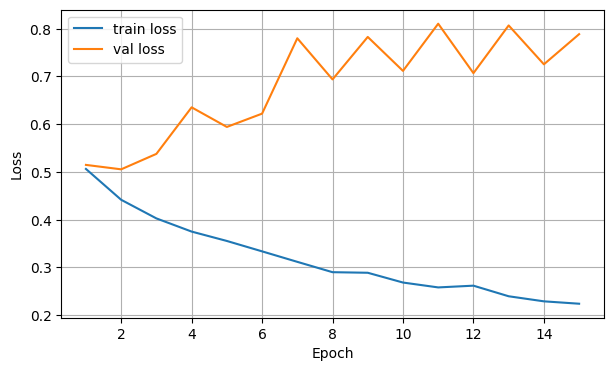

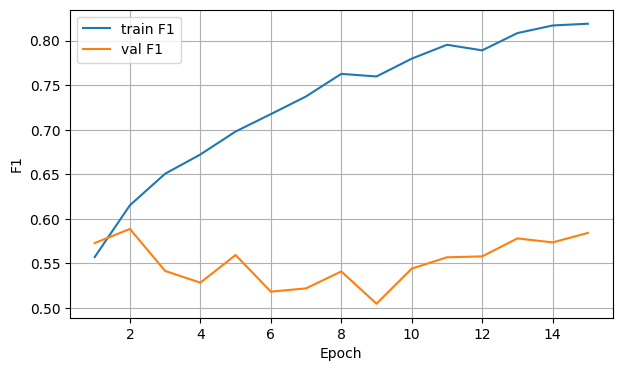

In [36]:
plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_f1"], label="train F1")
plt.plot(history_df["epoch"], history_df["val_f1"], label="val F1")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

val_metrics = run_one_epoch(model, val_loader, criterion, optimizer=None)

print("Best checkpoint epoch:", ckpt["epoch"])
print("Best checkpoint val F1:", ckpt["best_val_f1"])

print("\nValidation classification report:")
print(classification_report(
    val_metrics["labels"],
    val_metrics["preds"],
    target_names=["normal", "fall"],
    zero_division=0,
))

cm = confusion_matrix(val_metrics["labels"], val_metrics["preds"])
print("Confusion matrix:")
print(cm)

eval_report_path = LOGS_DIR / "best_checkpoint_eval_report_combined.txt"
with open(eval_report_path, "w") as f:
    f.write(f"Best checkpoint epoch: {ckpt['epoch']}\n")
    f.write(f"Best checkpoint val F1: {ckpt['best_val_f1']}\n\n")
    f.write(classification_report(
        val_metrics["labels"],
        val_metrics["preds"],
        target_names=["normal", "fall"],
        zero_division=0,
    ))
    f.write("\nConfusion matrix:\n")
    f.write(str(cm))

print("Saved eval report:", eval_report_path)

Best checkpoint epoch: 2
Best checkpoint val F1: 0.5886402753872634

Validation classification report:
              precision    recall  f1-score   support

      normal       0.86      0.84      0.85      2391
        fall       0.58      0.60      0.59       854

    accuracy                           0.78      3245
   macro avg       0.72      0.72      0.72      3245
weighted avg       0.78      0.78      0.78      3245

Confusion matrix:
[[2015  376]
 [ 341  513]]
Saved eval report: outputs/logs/best_checkpoint_eval_report_combined.txt


In [38]:
@torch.no_grad()
def get_val_probs(model, loader):
    model.eval()
    all_probs = []
    all_labels = []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)[:, 1]

        all_probs.extend(probs.detach().cpu().numpy().tolist())
        all_labels.extend(yb.numpy().tolist())

    return np.array(all_probs), np.array(all_labels)


fall_probs, true_labels = get_val_probs(model, val_loader)

rows = []

for thresh in np.arange(0.10, 0.96, 0.05):
    preds = (fall_probs >= thresh).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels,
        preds,
        average="binary",
        zero_division=0,
    )

    cm = confusion_matrix(true_labels, preds)
    tn, fp, fn, tp = cm.ravel()

    rows.append({
        "threshold": round(float(thresh), 2),
        "accuracy": accuracy_score(true_labels, preds),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "true_negatives": int(tn),
    })

threshold_df = pd.DataFrame(rows)

threshold_path = LOGS_DIR / "threshold_sweep_combined.csv"
threshold_df.to_csv(threshold_path, index=False)

print("Saved threshold sweep:", threshold_path)

print("Top thresholds by F1:")
display(threshold_df.sort_values("f1", ascending=False).head(10))

display(threshold_df)

Saved threshold sweep: outputs/logs/threshold_sweep_combined.csv
Top thresholds by F1:


,threshold,accuracy,precision,recall,f1,false_positives,false_negatives,true_positives,true_negatives
8,0.50,0.779045,0.577053,0.600703,0.588640,376,341,513,2015
11,0.65,0.819723,0.756190,0.464871,0.575780,128,457,397,2263
7,0.45,0.741140,0.506228,0.666276,0.575329,555,285,569,1836
9,0.55,0.792296,0.623626,0.531616,0.573957,274,400,454,2117
10,0.60,0.803390,0.673077,0.491803,0.568336,204,434,420,2187
5,0.35,0.675193,0.436387,0.803279,0.565540,886,168,686,1505
6,0.40,0.700770,0.457143,0.730679,0.562416,741,230,624,1650
12,0.70,0.820339,0.795207,0.427400,0.555979,94,489,365,2297
4,0.30,0.624653,0.399780,0.850117,0.543820,1090,128,726,1301
13,0.75,0.819414,0.828431,0.395785,0.535658,70,516,338,2321


,threshold,accuracy,precision,recall,f1,false_positives,false_negatives,true_positives,true_negatives
0,0.10,0.413559,0.308227,0.987119,0.469769,1892,11,843,499
1,0.15,0.464407,0.324464,0.956674,0.484579,1701,37,817,690
2,0.20,0.522650,0.346849,0.921546,0.504003,1482,67,787,909
3,0.25,0.574730,0.371707,0.892272,0.524793,1288,92,762,1103
4,0.30,0.624653,0.399780,0.850117,0.543820,1090,128,726,1301
5,0.35,0.675193,0.436387,0.803279,0.565540,886,168,686,1505
6,0.40,0.700770,0.457143,0.730679,0.562416,741,230,624,1650
7,0.45,0.741140,0.506228,0.666276,0.575329,555,285,569,1836
8,0.50,0.779045,0.577053,0.600703,0.588640,376,341,513,2015
9,0.55,0.792296,0.623626,0.531616,0.573957,274,400,454,2117


In [39]:
candidate_df = threshold_df[
    (threshold_df["recall"] >= 0.50) &
    (threshold_df["precision"] >= 0.35)
].copy()

if len(candidate_df) > 0:
    selected_row = candidate_df.sort_values(
        ["f1", "precision"],
        ascending=False
    ).iloc[0]
else:
    selected_row = threshold_df.sort_values("f1", ascending=False).iloc[0]

SELECTED_FALL_THRESHOLD = float(selected_row["threshold"])
CONFIG["fall_prob_threshold"] = SELECTED_FALL_THRESHOLD

print("Selected threshold:", SELECTED_FALL_THRESHOLD)
display(selected_row.to_frame().T)

Selected threshold: 0.5


,threshold,accuracy,precision,recall,f1,false_positives,false_negatives,true_positives,true_negatives
8,0.5,0.779045,0.577053,0.600703,0.58864,376.0,341.0,513.0,2015.0


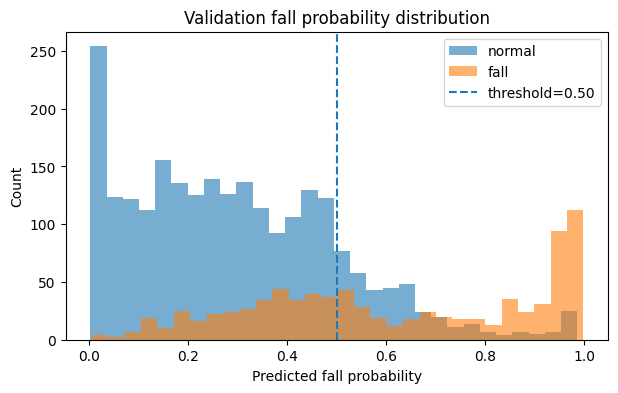

In [40]:
plt.figure(figsize=(7, 4))
plt.hist(fall_probs[true_labels == 0], bins=30, alpha=0.6, label="normal")
plt.hist(fall_probs[true_labels == 1], bins=30, alpha=0.6, label="fall")
plt.axvline(SELECTED_FALL_THRESHOLD, linestyle="--", label=f"threshold={SELECTED_FALL_THRESHOLD:.2f}")
plt.xlabel("Predicted fall probability")
plt.ylabel("Count")
plt.legend()
plt.title("Validation fall probability distribution")
plt.show()

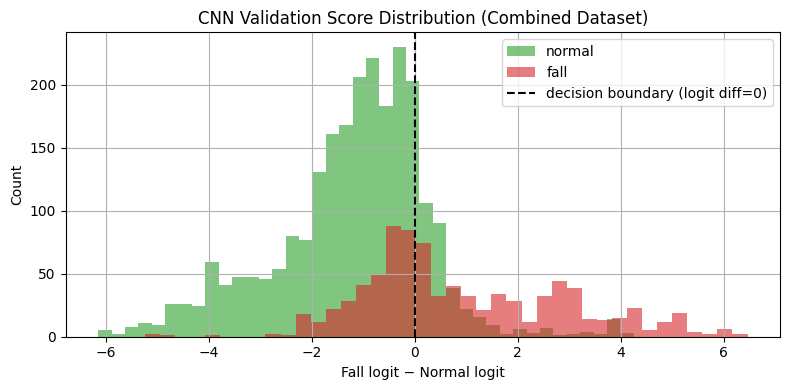

In [41]:
# CNN does not have attention weights — plot per-class score distributions
# as a replacement for the BiLSTM attention visualization.

@torch.no_grad()
def get_val_scores(model, loader):
    """Return (fall_logit - normal_logit) for every val sample."""
    model.eval()
    scores, labels = [], []
    for xb, yb in loader:
        logits = model(xb.to(DEVICE))
        margin = (logits[:, 1] - logits[:, 0]).cpu().numpy()
        scores.extend(margin.tolist())
        labels.extend(yb.numpy().tolist())
    return np.array(scores), np.array(labels)


val_scores, val_label_arr = get_val_scores(model, val_loader)

plt.figure(figsize=(8, 4))
plt.hist(val_scores[val_label_arr == 0], bins=40, alpha=0.6, label="normal", color="tab:green")
plt.hist(val_scores[val_label_arr == 1], bins=40, alpha=0.6, label="fall",   color="tab:red")
plt.axvline(0, linestyle="--", color="black", label="decision boundary (logit diff=0)")
plt.xlabel("Fall logit − Normal logit")
plt.ylabel("Count")
plt.title("CNN Validation Score Distribution (Combined Dataset)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [42]:
def heuristic_fall_score_from_records(window_records):
    """
    Heuristic score for poor-pose or occluded cases.

    Uses bbox motion:
    - vertical center drop
    - aspect ratio change
    - final bbox lower in frame than initial
    """

    if len(window_records) < 2:
        return 0.0

    centers_y = []
    aspects = []
    heights = []

    for rec in window_records:
        x1, y1, x2, y2 = rec["bbox_xyxy"]
        cx, cy, w, h = xyxy_to_xywh([x1, y1, x2, y2])

        centers_y.append(cy)
        aspects.append(w / max(h, 1.0))
        heights.append(h)

    centers_y = np.asarray(centers_y, dtype=np.float32)
    aspects = np.asarray(aspects, dtype=np.float32)
    heights = np.asarray(heights, dtype=np.float32)

    vertical_drop = centers_y[-1] - centers_y[0]
    max_drop = np.max(centers_y) - np.min(centers_y)

    aspect_change = aspects[-1] - aspects[0]
    height_drop = heights[0] - heights[-1]

    score = 0.0

    if vertical_drop > 25:
        score += 0.35

    if max_drop > 35:
        score += 0.25

    if aspect_change > 0.25:
        score += 0.20

    if height_drop > 20:
        score += 0.20

    return float(np.clip(score, 0.0, 1.0))


def route_window(window_records):
    good_count = sum(is_pose_good_enough(rec["keypoints"]) for rec in window_records)

    if good_count >= len(window_records) * 0.5:
        return "cnn"

    return "heuristic"

In [43]:
class FallEventState:
    def __init__(self, confirm_windows=3):
        self.confirm_windows = confirm_windows
        self.track_state = defaultdict(lambda: {
            "consecutive_fall": 0,
            "in_event": False,
            "event_start_frame": None,
            "last_fall_frame": None,
            "max_confidence": 0.0,
            "mode_used": None,
        })
        self.events = []

    def update(self, video_name, track_id, frame_idx, is_fall, confidence, mode):
        state = self.track_state[track_id]

        if is_fall:
            state["consecutive_fall"] += 1
            state["last_fall_frame"] = frame_idx
            state["max_confidence"] = max(state["max_confidence"], confidence)
            state["mode_used"] = mode

            if not state["in_event"] and state["consecutive_fall"] >= self.confirm_windows:
                state["in_event"] = True
                state["event_start_frame"] = frame_idx

        else:
            if state["in_event"]:
                event = {
                    "video_name": video_name,
                    "track_id": int(track_id),
                    "event_start_frame": int(state["event_start_frame"]),
                    "event_end_frame": int(state["last_fall_frame"]),
                    "confidence": float(state["max_confidence"]),
                    "mode_used": state["mode_used"],
                    "label": "fall",
                }
                self.events.append(event)

            state["consecutive_fall"] = 0
            state["in_event"] = False
            state["event_start_frame"] = None
            state["last_fall_frame"] = None
            state["max_confidence"] = 0.0
            state["mode_used"] = None

    def finalize(self, video_name):
        for track_id, state in self.track_state.items():
            if state["in_event"]:
                event = {
                    "video_name": video_name,
                    "track_id": int(track_id),
                    "event_start_frame": int(state["event_start_frame"]),
                    "event_end_frame": int(state["last_fall_frame"]),
                    "confidence": float(state["max_confidence"]),
                    "mode_used": state["mode_used"],
                    "label": "fall",
                }
                self.events.append(event)

        return self.events

In [48]:
@torch.no_grad()
def predict_cnn_window(model, window_records):
    features = []

    for rec in window_records:
        features.append(record_to_feature_vector(rec))

    seq = np.stack(features, axis=0).astype(np.float32)
    seq_tensor = torch.tensor(seq, dtype=torch.float32).transpose(0, 1).unsqueeze(0).to(DEVICE)

    logits = model(seq_tensor)
    probs = torch.softmax(logits, dim=1)[0]
    fall_prob = float(probs[1].detach().cpu().item())

    is_fall = fall_prob >= CONFIG["fall_prob_threshold"]

    return is_fall, fall_prob

Currently Training Have not tried inference

1. trying different methods to lessen the false positives for fall class

In [49]:



def run_full_inference_on_video(video_path, model, save_log=True):
    video_uid = re.sub(r"[^A-Za-z0-9]+", "_", str(Path(video_path).stem)).strip("_")
    records = load_or_extract_records(video_path, video_uid)

    if len(records) == 0:
        print("No records for video:", video_path)
        return pd.DataFrame()

    video_name = Path(video_path).name

    records = sorted(records, key=lambda r: (r["frame_idx"], r["track_id"]))

    buffers = defaultdict(lambda: deque(maxlen=CONFIG["seq_len"]))
    event_state = FallEventState(confirm_windows=CONFIG["confirm_windows"])

    for rec in tqdm(records, desc=f"Inference {video_name}"):
        tid = int(rec["track_id"])
        frame_idx = int(rec["frame_idx"])

        buffers[tid].append(rec)

        if len(buffers[tid]) < CONFIG["seq_len"]:
            continue

        window_records = list(buffers[tid])
        mode = route_window(window_records)

        if mode == "cnn":
            is_fall, confidence = predict_cnn_window(model, window_records)
        else:
            confidence = heuristic_fall_score_from_records(window_records)
            is_fall = confidence >= CONFIG["fall_prob_threshold"]

        event_state.update(
            video_name=video_name,
            track_id=tid,
            frame_idx=frame_idx,
            is_fall=is_fall,
            confidence=confidence,
            mode=mode,
        )

    events = event_state.finalize(video_name)
    events_df = pd.DataFrame(events)

    if save_log:
        log_path = LOGS_DIR / f"{Path(video_path).stem}_fall_events.csv"
        events_df.to_csv(log_path, index=False)
        print("Saved log:", log_path)

    return events_df


sample_events = run_full_inference_on_video(sample_video, model, save_log=True)
display(sample_events)

Tracking video (1).mp4: 157it [00:03, 47.69it/s]
Inference video (1).mp4: 100%|██████████| 161/161 [00:00<00:00, 227.81it/s]

Saved log: outputs/logs/video (1)_fall_events.csv


,video_name,track_id,event_start_frame,event_end_frame,confidence,mode_used,label
0,video (1).mp4,270,41,157,0.920889,cnn,fall


In [50]:
def run_inference_on_dataset(dataset_df, model, max_videos=None):
    usable_df = dataset_df.dropna(subset=["annotation_path"]).reset_index(drop=True)

    if max_videos is not None:
        usable_df = usable_df.iloc[:max_videos]

    all_events = []

    for _, row in tqdm(usable_df.iterrows(), total=len(usable_df), desc="Dataset inference"):
        video_path = row["video_path"]

        try:
            events_df = run_full_inference_on_video(video_path, model, save_log=True)
            if len(events_df) > 0:
                all_events.append(events_df)
        except Exception as e:
            print("Error:", row["video_name"], e)

    if len(all_events) == 0:
        return pd.DataFrame()

    return pd.concat(all_events, ignore_index=True)


# First try a few videos.
all_events_df = run_inference_on_dataset(dataset_df, model, max_videos=5)

display(all_events_df)

Dataset inference:   0%|          | 0/5 [00:00<?, ?it/s]

Dataset inference:  20%|██        | 1/5 [00:00<00:02,  1.46it/s]

Saved log: outputs/logs/video (1)_fall_events.csv


Tracking video (2).mp4: 306it [00:06, 48.32it/s]
Dataset inference:  40%|████      | 2/5 [00:08<00:14,  4.89s/it]

Saved log: outputs/logs/video (2)_fall_events.csv


...

Tracking video (4).mp4: 207it [00:04, 47.91it/s]
Dataset inference:  80%|████████  | 4/5 [00:21<00:05,  5.72s/it]

Saved log: outputs/logs/video (4)_fall_events.csv


Tracking video (5).mp4: 181it [00:03, 47.36it/s]
Dataset inference: 100%|██████████| 5/5 [00:25<00:00,  5.20s/it]

Saved log: outputs/logs/video (5)_fall_events.csv


,video_name,track_id,event_start_frame,event_end_frame,confidence,mode_used,label
0,video (1).mp4,270,41,157,0.920889,cnn,fall
1,video (2).mp4,276,33,33,0.535828,cnn,fall
2,video (2).mp4,276,61,125,0.587514,cnn,fall
3,video (2).mp4,276,208,306,0.933010,cnn,fall
4,video (3).mp4,278,39,39,0.590006,cnn,fall
5,video (3).mp4,278,83,123,0.546428,cnn,fall
6,video (3).mp4,278,242,304,0.938079,cnn,fall
7,video (4).mp4,279,46,48,0.660823,cnn,fall
8,video (4).mp4,279,132,137,0.543662,cnn,fall
9,video (5).mp4,285,33,37,0.629371,cnn,fall


In [51]:
def evaluate_video_level_events(dataset_df, events_df):
    rows = []

    for _, row in dataset_df.dropna(subset=["annotation_path"]).iterrows():
        video_name = row["video_name"]
        ann = parse_le2i_annotation(row["annotation_path"])

        gt_has_fall = ann["fall_end"] >= ann["fall_start"]

        pred_events = events_df[events_df["video_name"] == video_name] if len(events_df) else pd.DataFrame()
        pred_has_fall = len(pred_events) > 0

        rows.append({
            "video_name": video_name,
            "gt_has_fall": bool(gt_has_fall),
            "pred_has_fall": bool(pred_has_fall),
            "num_pred_events": int(len(pred_events)),
        })

    eval_df = pd.DataFrame(rows)

    if len(eval_df) > 0:
        print("Video-level detection summary:")
        print(pd.crosstab(eval_df["gt_has_fall"], eval_df["pred_has_fall"]))

    return eval_df


video_eval_df = evaluate_video_level_events(dataset_df, all_events_df)
display(video_eval_df.head())

Video-level detection summary:
pred_has_fall  False  True 
gt_has_fall                
True             136     20


,video_name,gt_has_fall,pred_has_fall,num_pred_events
0,video (1).mp4,True,True,1
1,video (2).mp4,True,True,3
2,video (3).mp4,True,True,3
3,video (4).mp4,True,True,2
4,video (5).mp4,True,True,2
